# 🛡️ Sentinel-Spark-IDS: Scalable Intrusion Detection System
---

## 📌 Project Overview
This project focuses on building a **high-performance, scalable Intrusion Detection System (IDS)** leveraging the [CIC-IDS-2017 Dataset](https://cicresearch.ca/CICDataset/CIC-IDS-2017/). By integrating a complete **Data Science Pipeline** with distributed computing, we address the critical challenge of monitoring massive network traffic for real-time cyber-attack detection.

The project is built on three core pillars:
1.  **Big Data:** Utilizing **Apache Spark (PySpark)** for distributed processing of millions of network flow records.
2.  **Advanced Data Science:** A rigorous pipeline for data cleaning, advanced feature engineering, and handling severe class imbalances.
3. **Applied Machine Learning:** Training high-performance classifiers (e.g., Random Forest, LightGBM) to distinguish between benign traffic and malicious activities.

---

## 🛠️ Data Science & ML Pipeline
Our methodology strictly adheres to the professional ML pipeline requirements:

| Stage | Focus | Key Operations |
| :--- | :--- | :--- |
| **1. Data Collection** | Retrieval | Efficient loading of 2.8M+ records via PySpark. |
| **2. Pre-processing** | Cleaning | Handling NaNs/Infs, duplicate removal, and schema standardization. |
| **3. Feature Engineering** | Extraction | Generating domain-specific metrics (e.g., flow ratios) to reveal attack patterns. |
| **4. Feature Selection** | Optimization | Using Correlation analysis and Feature Importance to reduce dimensionality. |
| **5. Imbalance Handling** | Sampling | Applying techniques to protect the model from "Benign" class bias. |
| **6. ML Core** | Training | Hyperparameter tuning and evaluation of Random Forest & LightGBM. |
| **7. Analytics** | Visualization | Storytelling through interactive dashboards and threat mapping. |

---

## 👥 Team Contributions
| Name | Role | Core Responsibility |
| :--- | :--- | :--- |
| **Mahmoud Shehta Mahmoud** | **Project Lead** | Architecture, Spark Engine Config & Integration. |
| **Mohamed Anwar Nassar** | **Data Engineer** | Cleaning Pipeline & Data Integrity. |
| **Ahmed Nassar Nassar** | **Feature Architect** | Extraction Logic & Selection Methods. |
| **Ahd Sayed Atia** | **Data Scientist** | Sampling Strategies & Class Imbalance. |
| **Reem Ahmed Maher** | **ML Engineer** | Model Training, Tuning & Evaluation. |

---
## 🌐 Threat Intelligence Context

In a modern **Security Operations Center (SOC)**, analysts deal with millions of events per second. Traditional tools often fail at this scale. This project simulates a professional environment where **AI meets Big Data** to provide:

*   **Automated Threat Response:** Minimizing the "Mean Time to Detect" (MTTD).
*   **Intelligence Monitoring:** Using ML to identify complex patterns (DDoS, Botnets) hidden in high-velocity traffic.

### **Live Global Cyberthreat Map**
Visualizing the scale of global cyber-attacks highlights why distributed computing (Spark) is essential for modern IDS.

In [ ]:
# @title 🔍 Real-time Global Threat Visualization { display-mode: "form" }
from IPython.display import IFrame, display, HTML

# Embed Kaspersky Cybermap for context
display(IFrame(src="https://cybermap.kaspersky.com/en/widget/dynamic/dark", width='100%', height='500'))

# Explanatory caption
display(HTML("""
<div style="text-align: center; color: #555; font-style: italic; margin-top: 10px;">
    <p>Visualizing real-world malicious activities (DDoS, Botnets, etc.) captured in datasets like CIC-IDS-2017.</p>
</div>
"""))

---
### **Step 1: Data Collection & Spark Environment Setup**
> **Assigned to:** *Mahmoud Shehta*

In this foundational step, we configure the distributed computing engine and perform high-velocity data ingestion of the **CIC-IDS-2017** dataset using **PySpark**.

*   **Task:** Scalable loading and schema standardization of network flow records.
*   **Requirements:** Document dataset structure and identify initial feature-target relationships.
*   **Objective:** Prepare a unified Spark DataFrame optimized for big data processing.
---

In [59]:
# Import Essential Libraries for Big Data & ML
import os
import re
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# 1. PySpark Core & SQL Functions
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

# 2. Spark MLlib for Data Pipeline
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, StandardScaler, StringIndexerModel
from pyspark.ml.classification import RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.stat import Correlation

# 3. Advanced ML (LightGBM for Distributed Big Data)
# Using SynapseML (formerly MMLSpark) to run LightGBM on top of Spark clusters
!pip install synapseml==0.11.1 -q

print("All core and LightGBM-specific libraries imported successfully.")

All core and LightGBM-specific libraries imported successfully.


In [60]:
# Step 1.1: Environment Setup & Google Drive Mounting
# This ensures persistent access to the CIC-IDS-2017 dataset stored in Drive
from google.colab import drive
import os
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Step 1.2: Dependencies Installation
# SynapseML is essential for running LightGBM on top of Apache Spark
!pip install pyspark synapseml==0.11.1 -q

# Step 1.3: Advanced Spark Session Initialization with LightGBM Support
# Crucial: We must stop any existing sessions to apply new JAR configurations
from pyspark.sql import SparkSession

if 'spark' in locals():
    spark.stop()

# Configure Spark to download necessary Java packages (JARs) for SynapseML
# Resource allocation is optimized for handling 2.8M records efficiently
spark = SparkSession.builder \
    .appName("Sentinel-Spark-IDS") \
    .config("spark.jars.packages", "com.microsoft.azure:synapseml_2.12:0.11.1") \
    .config("spark.jars.repositories", "https://mmlspark.azureedge.net/maven") \
    .config("spark.executor.memory", "4g") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.autoBroadcastJoinThreshold", "-1") \
    .getOrCreate()

# Step 1.4: Spark Performance Optimization
# Disabling constraint propagation improves execution speed for large schemas
spark.conf.set("spark.sql.constraintPropagation.enabled", "false")

print("Spark Session with SynapseML (LightGBM) support initialized successfully.")
print(f"Spark Version : {spark.version}")
print(f"App Name      : {spark.sparkContext.appName}")

Spark Session with SynapseML (LightGBM) support initialized successfully.
Spark Version : 4.0.2
App Name      : Sentinel-Spark-IDS


In [ ]:
# Step 1.4: High-Velocity Data Ingestion
# Using Wildcard (*.csv) to process all 8 network traffic files as one distributed object
data_path = "/content/drive/MyDrive/AML_BD_DS_Project/DateCVE/*.csv"

if os.path.exists(data_path.replace("*.csv", "")):
    df = spark.read.option("header", "True") \
                   .option("inferSchema", "True") \
                   .csv(data_path)

    total_records = df.count()
    total_features = len(df.columns)
    print(f"Total Records Ingested : {total_records:,}")
    print(f"Total Raw Features     : {total_features}")
else:
    print("Critical Error: Data path not found. Please verify your Drive directory.")

Total Records Ingested : 2,830,743
Total Raw Features     : 79


In [ ]:
# Step 1.5: Structural Inspection & Column Sanitization
# Critical: Removing white spaces from column names to prevent 'Unresolved Column' errors
sanitized_columns = [col.strip() for col in df.columns]
df = df.toDF(*sanitized_columns)

# Overview of data types and top records
df.printSchema()

root
 |-- Destination Port: integer (nullable = true)
 |-- Flow Duration: integer (nullable = true)
 |-- Total Fwd Packets: integer (nullable = true)
 |-- Total Backward Packets: integer (nullable = true)
 |-- Total Length of Fwd Packets: integer (nullable = true)
 |-- Total Length of Bwd Packets: integer (nullable = true)
 |-- Fwd Packet Length Max: integer (nullable = true)
 |-- Fwd Packet Length Min: integer (nullable = true)
 |-- Fwd Packet Length Mean: double (nullable = true)
 |-- Fwd Packet Length Std: double (nullable = true)
 |-- Bwd Packet Length Max: integer (nullable = true)
 |-- Bwd Packet Length Min: integer (nullable = true)
 |-- Bwd Packet Length Mean: double (nullable = true)
 |-- Bwd Packet Length Std: double (nullable = true)
 |-- Flow Bytes/s: double (nullable = true)
 |-- Flow Packets/s: double (nullable = true)
 |-- Flow IAT Mean: double (nullable = true)
 |-- Flow IAT Std: double (nullable = true)
 |-- Flow IAT Max: integer (nullable = true)
 |-- Flow IAT Min: in

In [ ]:
# Display first 5 rows to understand the structure
df.show(5, truncate=False)

print("Schema standardized and column headers cleaned.")

+----------------+-------------+-----------------+----------------------+---------------------------+---------------------------+---------------------+---------------------+----------------------+---------------------+---------------------+---------------------+----------------------+---------------------+------------+----------------+-------------+------------+------------+------------+-------------+------------+-----------+-----------+-----------+-------------+------------+-----------+-----------+-----------+-------------+-------------+-------------+-------------+-------------------+-----------------+----------------+-------------+-----------------+-----------------+------------------+-----------------+----------------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+-------------------+--------------------+--------------------+-------------------+------------------+--------------------+-------

In [ ]:
# Step 1.6: Target Label Distribution & Imbalance Analysis
# Identifying the ratio between 'Benign' and specific attack types
print("Traffic Class Counts:")
label_df = df.groupBy("Label").count().orderBy(F.desc("count"))
label_df.show()

# Compute imbalance ratio
label_counts_pd = label_df.toPandas()
imbalance_ratio = label_counts_pd['count'].max() / label_counts_pd['count'].min()
print(f"\nImbalance Ratio (Majority / Minority): {imbalance_ratio:,.0f} : 1")
print(f"Number of Distinct Classes          : {len(label_counts_pd)}")

Traffic Class Counts:
+--------------------+-------+
|               Label|  count|
+--------------------+-------+
|              BENIGN|2273097|
|            DoS Hulk| 231073|
|            PortScan| 158930|
|                DDoS| 128027|
|       DoS GoldenEye|  10293|
|         FTP-Patator|   7938|
|         SSH-Patator|   5897|
|       DoS slowloris|   5796|
|    DoS Slowhttptest|   5499|
|                 Bot|   1966|
|Web Attack � Brut...|   1507|
|    Web Attack � XSS|    652|
|        Infiltration|     36|
|Web Attack � Sql ...|     21|
|          Heartbleed|     11|
+--------------------+-------+


Imbalance Ratio (Majority / Minority): 206,645 : 1
Number of Distinct Classes          : 15


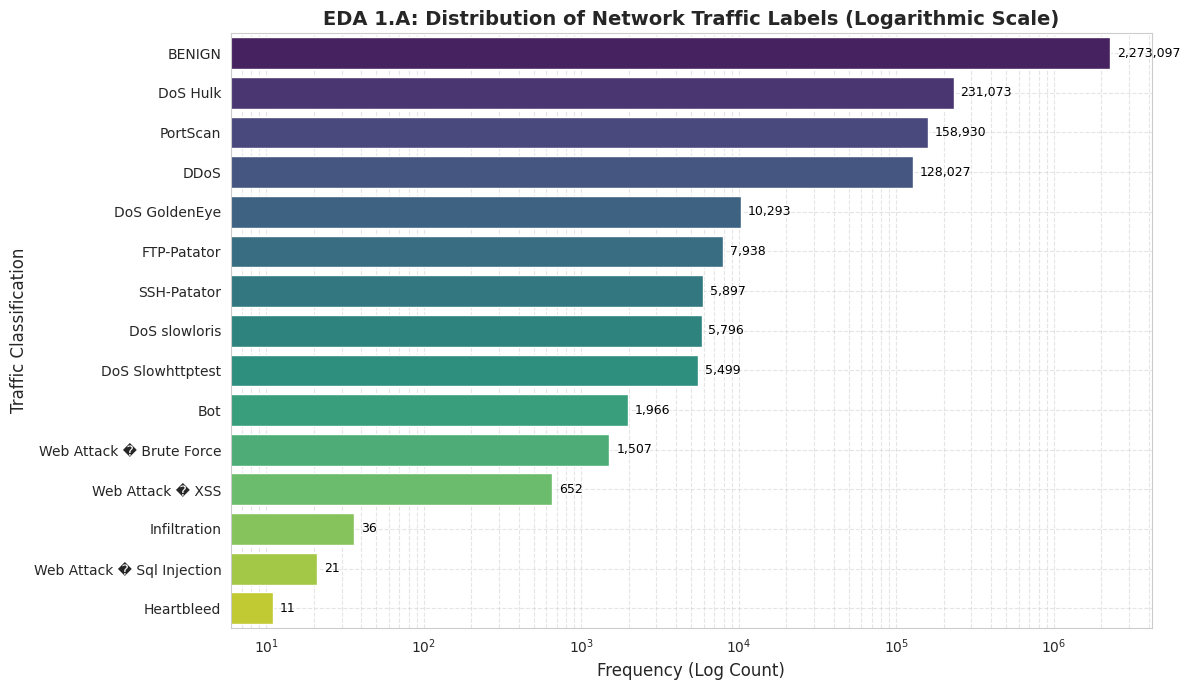

In [ ]:
# EDA 1.A: Bar Chart - Label Distribution (Log Scale)
# Log scale is essential due to the massive gap between Benign and Attacks
label_counts_pd = df.groupBy("Label").count().toPandas().sort_values('count', ascending=False)

plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
plot = sns.barplot(x='count', y='Label', data=label_counts_pd,
                   palette='viridis', hue='Label', legend=False)
plot.set_xscale('log')
plt.title("EDA 1.A: Distribution of Network Traffic Labels (Logarithmic Scale)", fontsize=14, fontweight='bold')
plt.xlabel("Frequency (Log Count)", fontsize=12)
plt.ylabel("Traffic Classification", fontsize=12)
plt.grid(True, which="both", ls="--", alpha=0.5)
# Annotate each bar with the exact count
for p in plot.patches:
    plot.annotate(f'{int(p.get_width()):,}',
                  (p.get_width(), p.get_y() + p.get_height() / 2),
                  ha='left', va='center', fontsize=9, color='black', xytext=(5, 0),
                  textcoords='offset points')
plt.tight_layout()
plt.show()

In [ ]:
# EDA 1.B: Pie Chart - Class Proportion
# Highlights the dominance of Benign traffic vs attack types
fig = px.pie(
    label_counts_pd,
    values='count',
    names='Label',
    title='EDA 1.B: Traffic Class Proportions (Raw Dataset)',
    color_discrete_sequence=px.colors.qualitative.Vivid,
    hole=0.3
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(showlegend=True, legend_title_text='Traffic Type')
fig.show()

Columns with missing/NaN values: 1
              null_count
Flow Bytes/s        1358


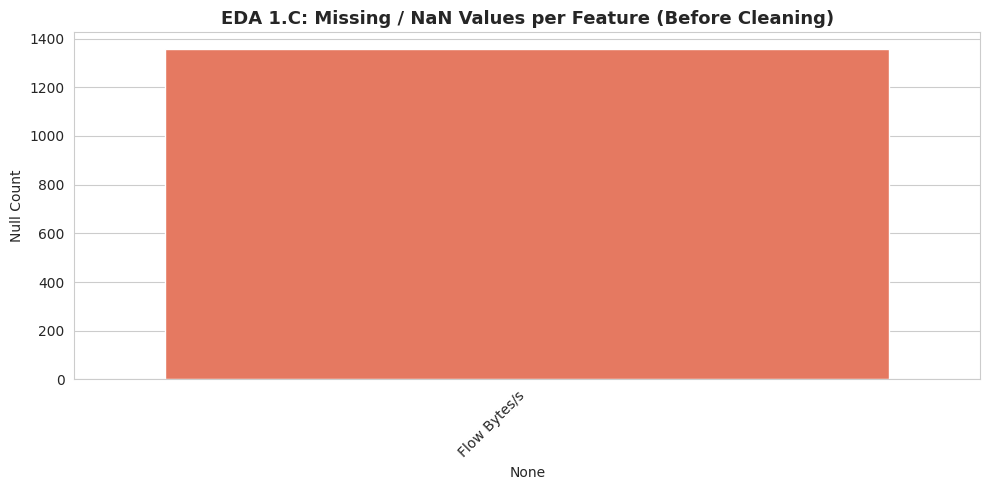

In [ ]:
# EDA 1.C: Missing Value Analysis Before Cleaning
# Count nulls and infinities per numeric column to quantify noise level
from pyspark.sql.functions import col, isnan, when, count

numeric_cols_raw = [f.name for f in df.schema.fields
                    if isinstance(f.dataType, (DoubleType, IntegerType, LongType, FloatType))]

# Count nulls per column
null_counts = df.select([
    count(when(isnan(c) | col(c).isNull(), c)).alias(c)
    for c in numeric_cols_raw
]).toPandas().T

null_counts.columns = ['null_count']
null_counts = null_counts[null_counts['null_count'] > 0].sort_values('null_count', ascending=False)

print(f"Columns with missing/NaN values: {len(null_counts)}")
print(null_counts)

if not null_counts.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=null_counts.index, y='null_count', data=null_counts, palette='Reds_r')
    plt.title('EDA 1.C: Missing / NaN Values per Feature (Before Cleaning)', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Null Count')
    plt.tight_layout()
    plt.show()
else:
    print("No null values detected in raw numeric columns.")

In [ ]:
# EDA 1.D: Statistical Summary of Raw Features
# Provides an overview of scale and distribution of key numeric columns
key_cols = ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
            'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean']

# Filter only existing columns
available_key_cols = [c for c in key_cols if c in df.columns]

print("Statistical Summary of Key Raw Features:")
df.select(available_key_cols).describe().show()

# Optimization: Persist the DataFrame in memory for faster cleaning & tidying stages
df.cache()
print("\nDataFrame cached in memory for optimized processing.")

Statistical Summary of Key Raw Features:
+-------+--------------------+-----------------+----------------------+------------+--------------+------------------+
|summary|       Flow Duration|Total Fwd Packets|Total Backward Packets|Flow Bytes/s|Flow Packets/s|Packet Length Mean|
+-------+--------------------+-----------------+----------------------+------------+--------------+------------------+
|  count|             2830743|          2830743|               2830743|     2830743|       2830743|           2830743|
|   mean|1.4785663929521684E7|9.361159949878884|    10.393770116185044|         NaN|      Infinity|171.94439024894086|
| stddev|3.3653744085855074E7|749.6727924979915|     997.3882689050994|         NaN|           NaN|305.49146113948694|
|    min|                 -13|                1|                     0|     -2.61E8|    -2000000.0|               0.0|
|    max|           119999998|           219759|                291922|         NaN|      Infinity|       3337.142857|
+------

---
### **Step 2: Data Tidying & Cleaning**
> **Assigned to:** *Mohamed Anwar*

Raw network traffic often contains noise and inconsistencies. This stage ensures data integrity by handling mathematical errors (Infs), missing values (NaNs), redundant features, and duplicate records.

*   **Tasks:** Column standardization, duplicate removal, handling infinite/null values, and dropping redundant/zero-variance features.
*   **EDA Integration:** Statistical profiling before and after cleaning to quantify improvements.
---

In [ ]:
# EDA 2.A: Record Count Before Any Cleaning
# Establish a baseline count to measure data loss at each cleaning step
initial_count = df.count()
print(f"Records BEFORE Cleaning : {initial_count:,}")
print(f"Features BEFORE Cleaning: {len(df.columns)}")

Records BEFORE Cleaning : 2,830,743
Features BEFORE Cleaning: 79


In [ ]:
# Step 2.1: Column Sanitation & Redundancy Removal

# 2.1.1. Clean column names by stripping extra spaces
# Prevents 'AnalysisException: Unresolved attribute' during distributed queries
clean_column_map = {c: c.strip() for c in df.columns}
for old_name, new_name in clean_column_map.items():
    if old_name != new_name:
        df = df.withColumnRenamed(old_name, new_name)
        print(f"Fixed column name: '{old_name}' -> '{new_name}'")

# 2.1.2. Standardize the label column name to exactly 'Label'
actual_cols = df.columns
label_candidates = [c for c in actual_cols if c.lower().strip() == 'label']
if label_candidates and label_candidates[0] != 'Label':
    df = df.withColumnRenamed(label_candidates[0], "Label")
    print(f"Standardized Label column: '{label_candidates[0]}' -> 'Label'")

# 2.1.3. Drop the well-known duplicated column in CIC-IDS-2017
if "Fwd Header Length.1" in df.columns:
    df = df.drop("Fwd Header Length.1")
    print("Dropped duplicated column: 'Fwd Header Length.1'")

# 2.1.4. Drop fully duplicated rows
before_dedup = df.count()
df = df.dropDuplicates()
after_dedup = df.count()
removed_dupes = before_dedup - after_dedup
print(f"\nRemoved {removed_dupes:,} duplicate rows  ({removed_dupes/before_dedup*100:.2f}% of data).")
print(f"Records after deduplication: {after_dedup:,}")


Removed 308,381 duplicate rows  (10.89% of data).
Records after deduplication: 2,522,362


In [ ]:
# Step 2.1.5: Drop Zero-Variance Features
# Constant columns carry no discriminative information for the model
numeric_cols = [f.name for f in df.schema.fields
                if isinstance(f.dataType, (DoubleType, IntegerType, LongType, FloatType))
                and f.name != 'Label']

summary = df.select(numeric_cols).summary("stddev").collect()[0]
zero_variance_cols = [col_name for col_name in numeric_cols
                      if float(summary[col_name] or 0) == 0.0]

if zero_variance_cols:
    print(f"Dropping {len(zero_variance_cols)} constant (zero-variance) columns:")
    for c in zero_variance_cols:
        print(f"  - {c}")
    df = df.drop(*zero_variance_cols)
else:
    print("No zero-variance columns detected.")

print(f"\nTotal features after redundancy cleaning: {len(df.columns)}")

Dropping 8 constant (zero-variance) columns:
  - Bwd PSH Flags
  - Bwd URG Flags
  - Fwd Avg Bytes/Bulk
  - Fwd Avg Packets/Bulk
  - Fwd Avg Bulk Rate
  - Bwd Avg Bytes/Bulk
  - Bwd Avg Packets/Bulk
  - Bwd Avg Bulk Rate

Total features after redundancy cleaning: 71


In [ ]:
# Step 2.2: Handling Mathematical Inconsistencies (Inf & NaN)
# Infinity values arise from division-by-zero in flow rate calculations
from pyspark.sql.functions import col, when

float_cols = [f.name for f in df.schema.fields
              if isinstance(f.dataType, (DoubleType, FloatType))]

# Replace +Inf and -Inf with Null, then drop those rows
inf_replacement_count = 0
for c in float_cols:
    df = df.withColumn(c, when(col(c).isin(float('inf'), float('-inf')), None).otherwise(col(c)))

before_null_drop = df.count()
df_cleaned = df.na.drop()
after_null_drop = df_cleaned.count()

print(f"Records removed due to Inf/Null values : {before_null_drop - after_null_drop:,}")
print(f"Final record count after Inf/Null removal: {after_null_drop:,}")

Records removed due to Inf/Null values : 1,564
Final record count after Inf/Null removal: 2,520,798


In [ ]:
# Step 2.2.2: Advanced Label Cleaning using Regex
# Handles encoding issues in CIC-IDS-2017 by removing non-alphanumeric characters
# and standardizing attack names for consistent visualization and model training
from pyspark.sql.functions import regexp_replace, trim

# 1. Remove non-alphanumeric characters (keep letters, numbers, hyphens, spaces)
df_cleaned = df_cleaned.withColumn("Label",
    regexp_replace(col("Label"), r"[^a-zA-Z0-9\-\s]", " "))

# 2. Collapse multiple whitespace into a single space
df_cleaned = df_cleaned.withColumn("Label",
    trim(regexp_replace(col("Label"), r"\s+", " ")))

# 3. Standardize Web Attack sub-category naming
label_mapping = {
    "Web Attack Brute Force"  : "Web Attack - Brute Force",
    "Web Attack XSS"          : "Web Attack - XSS",
    "Web Attack Sql Injection": "Web Attack - SQL Injection"
}
for corrupt, clean in label_mapping.items():
    df_cleaned = df_cleaned.withColumn("Label",
        when(col("Label") == corrupt, clean).otherwise(col("Label")))

print("Final Cleaned Attack Labels:")
df_cleaned.select("Label").distinct().show(truncate=False)

Final Cleaned Attack Labels:
+--------------------------+
|Label                     |
+--------------------------+
|BENIGN                    |
|SSH-Patator               |
|Web Attack - Brute Force  |
|Infiltration              |
|DoS slowloris             |
|DoS Hulk                  |
|Web Attack - SQL Injection|
|PortScan                  |
|DoS Slowhttptest          |
|Bot                       |
|Web Attack - XSS          |
|DoS GoldenEye             |
|DDoS                      |
|FTP-Patator               |
|Heartbleed                |
+--------------------------+



In [ ]:
# Step 2.2.3: Remove Physically Impossible (Negative) Values
# Flow duration and packet counts cannot be negative in real network traffic
negative_sensitive_cols = [
    "Flow Duration", "Total Fwd Packets",
    "Total Backward Packets", "Flow IAT Mean"
]
before_neg = df_cleaned.count()
for c in negative_sensitive_cols:
    if c in df_cleaned.columns:
        df_cleaned = df_cleaned.filter(col(c) >= 0)

after_neg = df_cleaned.count()
print(f"Records removed due to negative values: {before_neg - after_neg:,}")
print(f"Data reliability verified (No negative values in sensitive columns).")

Records removed due to negative values: 107
Data reliability verified (No negative values in sensitive columns).


Attack Category Profiles (Post-Cleaning):
+--------------------------+------------------+------------------+------------+
|Label                     |Avg_Packet_Size   |Std_Packet_Size   |Record_Count|
+--------------------------+------------------+------------------+------------+
|Heartbleed                |1626.6023184545456|31.29287123068875 |11          |
|DoS Hulk                  |791.1065268627867 |296.18430272089233|172846      |
|DDoS                      |736.9488114718961 |584.5400828126681 |128014      |
|DoS GoldenEye             |501.49966928837256|358.7322823896893 |10286       |
|Web Attack - SQL Injection|166.38292448571428|169.69945681478646|21          |
|Infiltration              |161.1012923598889 |135.92966574823248|36          |
|BENIGN                    |115.89795343155372|192.928932374354  |2094950     |
|DoS Slowhttptest          |83.05428722559675 |160.32126972132477|5228        |
|SSH-Patator               |81.20720746105923 |24.236407123772267|3219        

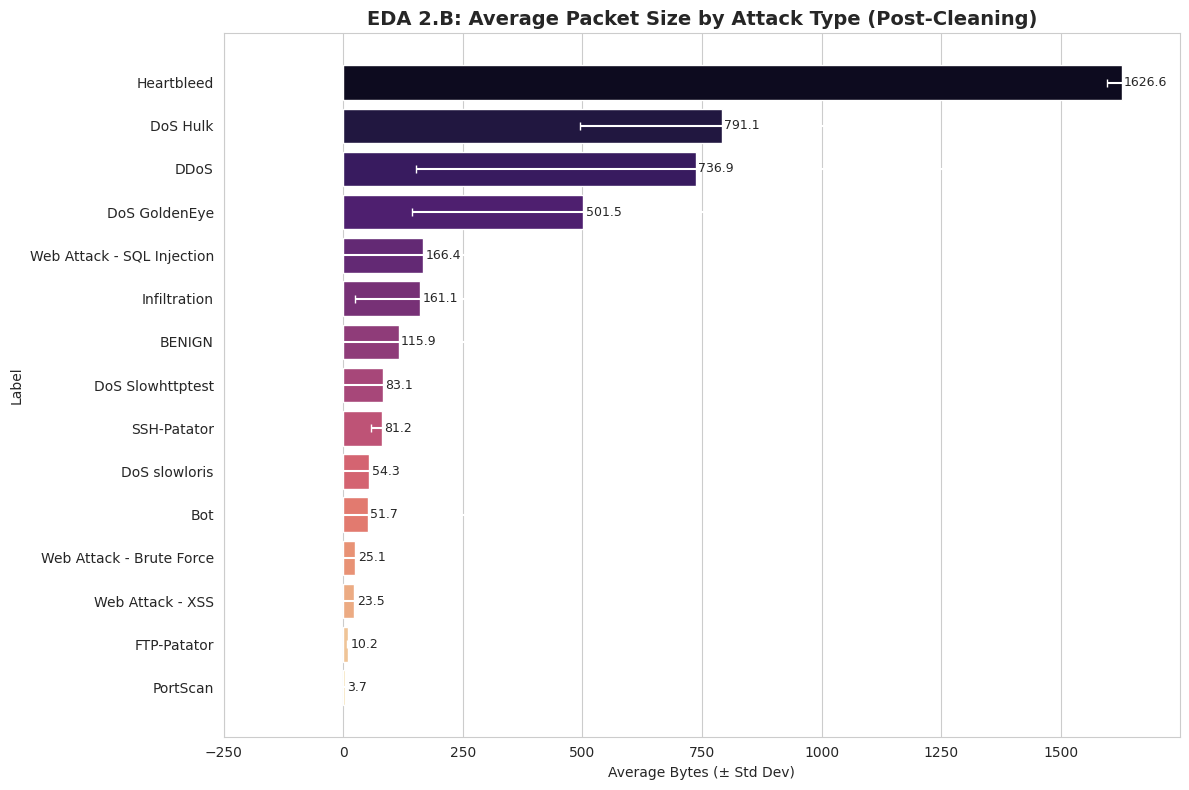

In [ ]:
# EDA 2.B: Attack Profile After Cleaning - Average Packet Size per Class
# This reveals behavioral signatures unique to each attack type
attack_profile = df_cleaned.groupBy("Label") \
    .agg(
        F.mean("Packet Length Mean").alias("Avg_Packet_Size"),
        F.stddev("Packet Length Mean").alias("Std_Packet_Size"),
        F.count("Label").alias("Record_Count")
    ).orderBy(F.desc("Avg_Packet_Size"))

print("Attack Category Profiles (Post-Cleaning):")
attack_profile.show(truncate=False)

profile_pd = attack_profile.toPandas()

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
ax = sns.barplot(x='Avg_Packet_Size', y='Label', data=profile_pd,
                 palette='magma', hue='Label', legend=False)
# Add error bars representing std deviation
for i, (avg, std) in enumerate(zip(profile_pd['Avg_Packet_Size'], profile_pd['Std_Packet_Size'])):
    ax.errorbar(avg, i, xerr=std if pd.notna(std) else 0, fmt='none', color='white', capsize=3)
    ax.annotate(f'{avg:.1f}', (avg + 5, i), va='center', fontsize=9)
plt.title("EDA 2.B: Average Packet Size by Attack Type (Post-Cleaning)", fontsize=14, fontweight='bold')
plt.xlabel("Average Bytes (± Std Dev)")
plt.tight_layout()
plt.show()


=== Cleaning Impact Summary ===
              Stage  Record_Count  Records_Lost  Pct_Retained
      Raw Ingestion       2830743           NaN        100.00
After Deduplication       2522362      308381.0         89.11
After Inf/Null Drop       2520798        1564.0         89.05
After Negative Drop       2520691         107.0         89.05


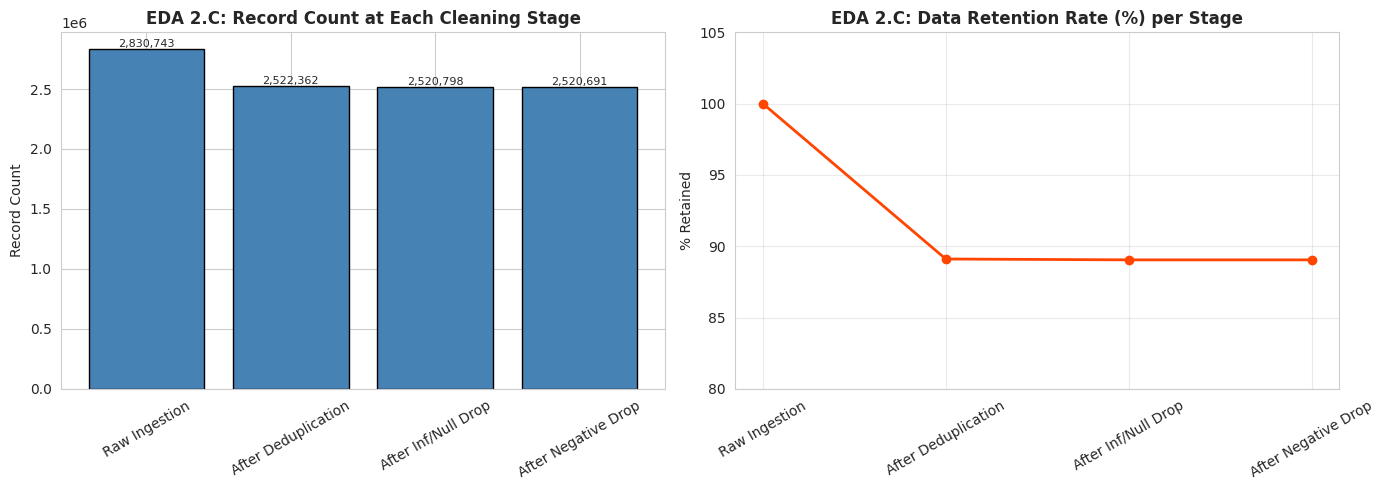

In [ ]:
# EDA 2.C: Cleaning Impact Summary - Data Loss Tracker
# A consolidated view of how many records were removed at each cleaning stage
cleaning_steps = [
    ('Raw Ingestion',       initial_count),
    ('After Deduplication', after_dedup),
    ('After Inf/Null Drop', after_null_drop),
    ('After Negative Drop', df_cleaned.count())
]
cleaning_df = pd.DataFrame(cleaning_steps, columns=['Stage', 'Record_Count'])
cleaning_df['Records_Lost'] = cleaning_df['Record_Count'].shift(1) - cleaning_df['Record_Count']
cleaning_df['Pct_Retained'] = (cleaning_df['Record_Count'] / initial_count * 100).round(2)

print("\n=== Cleaning Impact Summary ===")
print(cleaning_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Record count per stage
axes[0].bar(cleaning_df['Stage'], cleaning_df['Record_Count'], color='steelblue', edgecolor='black')
axes[0].set_title('EDA 2.C: Record Count at Each Cleaning Stage', fontweight='bold')
axes[0].set_ylabel('Record Count')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[0].patches, cleaning_df['Record_Count']):
    axes[0].annotate(f'{val:,}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=8)

# Right: Percentage retained
axes[1].plot(cleaning_df['Stage'], cleaning_df['Pct_Retained'],
             marker='o', color='orangered', linewidth=2)
axes[1].set_ylim(80, 105)
axes[1].set_title('EDA 2.C: Data Retention Rate (%) per Stage', fontweight='bold')
axes[1].set_ylabel('% Retained')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
sample_output_path = "/content/drive/MyDrive/AML_BD_DS_Project/sample_prediction_data.parquet"

# Load the pre-processed data (without balancing, as prediction input shouldn't be balanced)
df_for_sampling = spark.read.parquet("/content/drive/MyDrive/AML_BD_DS_Project/df_selected.parquet")

# Take a small sample (e.g., 100 records) and drop the 'label' column
sample_df = df_for_sampling.sample(False, 0.0001, seed=42).limit(100).drop("label")

# Ensure the sample is not empty
if sample_df.count() == 0:
    # If the initial sample was too small and resulted in 0 records, try again with a larger fraction
    sample_df = df_for_sampling.sample(False, 0.001, seed=42).limit(100).drop("label")

if sample_df.count() > 0:
    sample_df.write.mode("overwrite").parquet(sample_output_path)
    print(f"Sample prediction Parquet file generated successfully at: {sample_output_path}")
    print(f"Number of records in sample file: {sample_df.count()}")
    print(f"Sample schema:")
    sample_df.printSchema()
else:
    print("Could not generate a non-empty sample Parquet file.")

Sample prediction Parquet file generated successfully at: /content/drive/MyDrive/AML_BD_DS_Project/sample_prediction_data.parquet
Number of records in sample file: 100
Sample schema:
root
 |-- destination_port: integer (nullable = true)
 |-- total_length_of_fwd_packets: integer (nullable = true)
 |-- total_length_of_bwd_packets: integer (nullable = true)
 |-- fwd_packet_length_max: integer (nullable = true)
 |-- fwd_packet_length_min: integer (nullable = true)
 |-- fwd_packet_length_mean: double (nullable = true)
 |-- bwd_packet_length_min: integer (nullable = true)
 |-- bwd_packet_length_std: double (nullable = true)
 |-- flow_bytes_per_s: double (nullable = true)
 |-- flow_packets_per_s: double (nullable = true)
 |-- flow_iat_mean: double (nullable = true)
 |-- flow_iat_max: integer (nullable = true)
 |-- flow_iat_min: integer (nullable = true)
 |-- fwd_iat_total: integer (nullable = true)
 |-- fwd_iat_min: integer (nullable = true)
 |-- bwd_iat_total: integer (nullable = true)
 |-- 

In [ ]:
# Step 2.3: Feature Name Normalization
# Convert names into a programming-friendly format (no spaces or special symbols)
# This is critical for Spark ML pipelines and Streamlit deployment compatibility
def clean_column_name(name):
    name = name.replace("/", "_per_")
    name = name.replace(" ", "_")
    name = re.sub(r'[^a-zA-Z0-9_]', '', name)
    return name.lower()

new_names = [clean_column_name(c) for c in df_cleaned.columns]
df_cleaned = df_cleaned.toDF(*new_names)

print("Column names normalized for easy deployment access.")
print(f"Sample normalized names: {new_names[:5]}")

Column names normalized for easy deployment access.
Sample normalized names: ['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'total_length_of_fwd_packets']


In [ ]:
# Step 2.4: Optimized Data Persistence
# Parquet format is columnar and compressed - ideal for Spark-based workloads
output_path = "/content/drive/MyDrive/AML_BD_DS_Project/cleaned_data.parquet"
df_cleaned.write.mode("overwrite").parquet(output_path)

final_clean_count = df_cleaned.count()
print(f"Cleaned data saved to: {output_path}")
print(f"Final record count    : {final_clean_count:,}")
print(f"Final feature count   : {len(df_cleaned.columns)}")
print(f"Data retained         : {final_clean_count/initial_count*100:.2f}%")

# ──────────────────────────────────────────────────────────────
# [Anti-Leakage] Stratified Holdout Split
# ── Why stratified instead of randomSplit? ──────────────────
# randomSplit gives TINY classes (Heartbleed=11, SQL Inj=21,
# Infiltration=36) only 2-7 test records → F1=0 regardless of
# model quality. Stratified split guarantees every class keeps
# its 80/20 ratio, so even the rarest attack is represented.
# ─────────────────────────────────────────────────────────────
TEST_FRACTION = 0.20
SEED          = 42

from pyspark.sql import Window
import pyspark.sql.functions as F

w = Window.partitionBy("Label").orderBy(F.monotonically_increasing_id())

df_with_rank = df_cleaned.withColumn("_rank", F.row_number().over(w)) \
                         .withColumn("_total", F.count("*").over(Window.partitionBy("Label")))

df_test_holdout = df_with_rank.filter(
    F.col("_rank") <= F.greatest(F.lit(2), (F.col("_total") * TEST_FRACTION).cast("int"))
).drop("_rank", "_total")

df_train_holdout = df_with_rank.filter(
    F.col("_rank") > F.greatest(F.lit(2), (F.col("_total") * TEST_FRACTION).cast("int"))
).drop("_rank", "_total")

df_test_holdout.write.mode("overwrite").parquet(
    "/content/drive/MyDrive/AML_BD_DS_Project/df_test_holdout.parquet")

print(f"✅ Stratified split complete")
print("\nClass distribution in test holdout:")
df_test_holdout.groupBy("Label").count().orderBy(F.asc("count")).show(20, truncate=False)

Cleaned data saved to: /content/drive/MyDrive/AML_BD_DS_Project/cleaned_data.parquet
Final record count    : 2,520,691
Final feature count   : 71
Data retained         : 89.05%
✅ Stratified split complete

Class distribution in test holdout:
+--------------------------+------+
|Label                     |count |
+--------------------------+------+
|Heartbleed                |2     |
|Web Attack - SQL Injection|4     |
|Infiltration              |7     |
|Web Attack - XSS          |130   |
|Web Attack - Brute Force  |294   |
|Bot                       |389   |
|SSH-Patator               |643   |
|DoS Slowhttptest          |1045  |
|DoS slowloris             |1077  |
|FTP-Patator               |1186  |
|DoS GoldenEye             |2057  |
|PortScan                  |18138 |
|DDoS                      |25602 |
|DoS Hulk                  |34569 |
|BENIGN                    |418990|
+--------------------------+------+



---
### **Step 3: Feature Extraction & Engineering**
> **Assigned to:** *Ahmed Nassar*

In this stage, we transform raw network metrics into high-level behavioral indicators. By creating ratios and variability metrics, we expose hidden patterns that help the model distinguish between standard user behavior and sophisticated cyber-attacks.

*   **Goal:** Enhance model interpretability and predictive power through domain-specific feature engineering.
*   **Methodology:** Implementing flow-based ratios and statistical variability indicators.
---

#### **3.1 Loading Pre-processed Data**

In [ ]:
# Loading the standardized Parquet file to maintain data integrity and speed up processing
df_cleaned = spark.read.parquet("/content/drive/MyDrive/AML_BD_DS_Project/cleaned_data.parquet")

print(f"Loaded cleaned data: {df_cleaned.count():,} records, {len(df_cleaned.columns)} features")

Loaded cleaned data: 2,520,691 records, 71 features


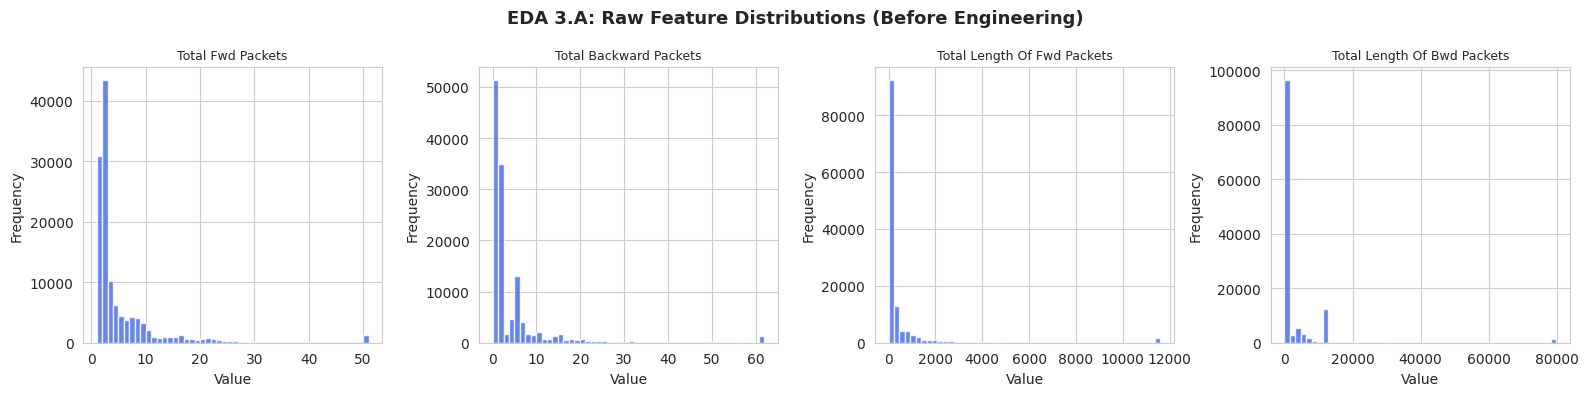

In [ ]:
# EDA 3.A: Baseline Feature Distribution Before Engineering
# Visualize the raw distributions of features that will be used in ratio calculations
baseline_features = [
    'total_fwd_packets', 'total_backward_packets',
    'total_length_of_fwd_packets', 'total_length_of_bwd_packets'
]
available_baseline = [c for c in baseline_features if c in df_cleaned.columns]

sample_pd = df_cleaned.select(available_baseline + ['label']).sample(0.05, seed=42).toPandas()

fig, axes = plt.subplots(1, len(available_baseline), figsize=(16, 4))
for ax, feat in zip(axes, available_baseline):
    sample_pd[feat].clip(upper=sample_pd[feat].quantile(0.99)).hist(
        bins=50, ax=ax, color='royalblue', edgecolor='white', alpha=0.8
    )
    ax.set_title(feat.replace('_', ' ').title(), fontsize=9)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.suptitle('EDA 3.A: Raw Feature Distributions (Before Engineering)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#### **3.2 Engineering Behavioral Features**

In [ ]:
# Creating complex behavioral features using optimized Spark functions.
# Each feature captures a specific network behavior pattern:
# - fwd_bwd_packet_ratio   : Asymmetry in packet flow (high = scan/DDoS)
# - fwd_bwd_byte_ratio     : Asymmetry in byte volume (high = data exfiltration)
# - packet_size_variability: Size variation (high = mixed attack traffic)
# - active_idle_ratio      : Connection burstiness (high = flooding attacks)
# - payload_intensity      : Bytes per unit time (high = volumetric attacks)
# - total_flow_intensity   : Packets per unit time (high = DDoS)
df_extracted = df_cleaned \
    .withColumn("fwd_bwd_packet_ratio",
                F.when(F.col("total_backward_packets") == 0, 0.0)
                .otherwise(F.col("total_fwd_packets") / F.col("total_backward_packets"))) \
    .withColumn("fwd_bwd_byte_ratio",
                F.when(F.col("total_length_of_bwd_packets") == 0, 0.0)
                .otherwise(F.col("total_length_of_fwd_packets") / F.col("total_length_of_bwd_packets"))) \
    .withColumn("packet_size_variability",
                F.when(F.col("min_packet_length") == 0, 0.0)
                .otherwise(F.col("max_packet_length") / F.col("min_packet_length"))) \
    .withColumn("active_idle_ratio",
                F.when(F.col("idle_mean") == 0, 0.0)
                .otherwise(F.col("active_mean") / F.col("idle_mean"))) \
    .withColumn("payload_intensity",
                (F.col("total_length_of_fwd_packets") + F.col("total_length_of_bwd_packets"))
                / (F.col("flow_duration") + 1)) \
    .withColumn("total_flow_intensity",
                (F.col("total_fwd_packets") + F.col("total_backward_packets"))
                / (F.col("flow_duration") + 1))

# Note: +1 is added to denominators to prevent division by zero during distributed computation
print("Behavioral features engineered successfully.")
print(f"Total features after engineering: {len(df_extracted.columns)}")
print("New features added:")
new_features = [
    'fwd_bwd_packet_ratio', 'fwd_bwd_byte_ratio', 'packet_size_variability',
    'active_idle_ratio', 'payload_intensity', 'total_flow_intensity'
]
for f in new_features:
    print(f"  + {f}")

Behavioral features engineered successfully.
Total features after engineering: 77
New features added:
  + fwd_bwd_packet_ratio
  + fwd_bwd_byte_ratio
  + packet_size_variability
  + active_idle_ratio
  + payload_intensity
  + total_flow_intensity


#### **3.3 EDA & Visualization of Engineered Features**

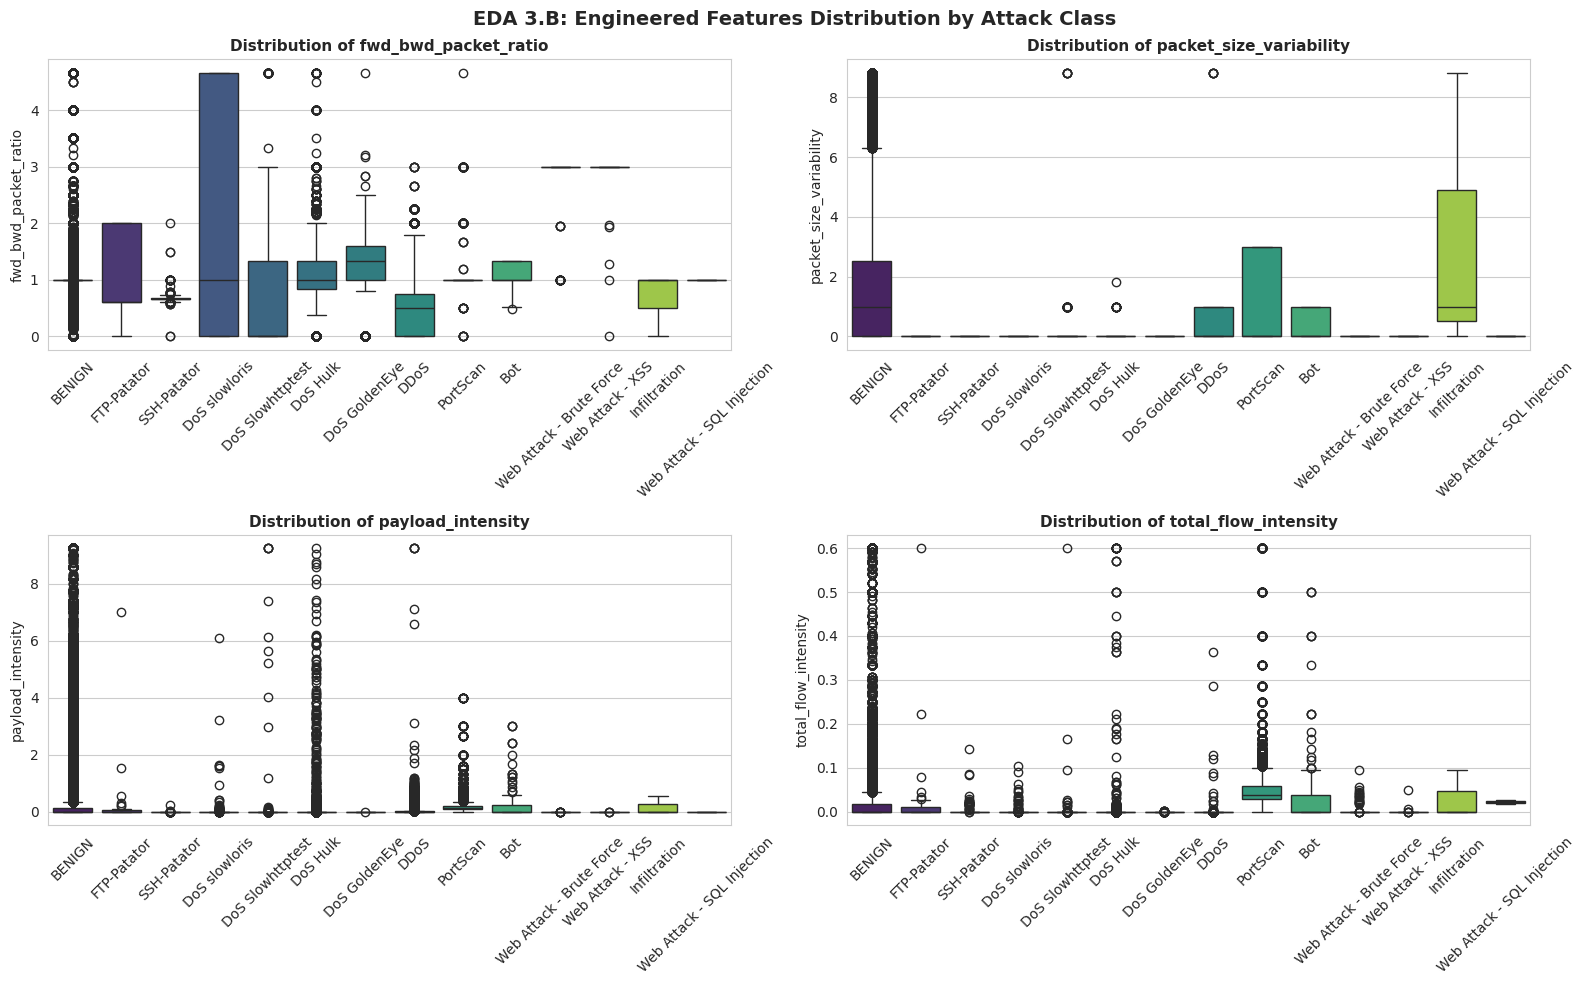

In [ ]:
# EDA 3.B: Engineered Feature Distributions - Box Plots
# Box plots reveal how each engineered feature separates attack classes
viz_sample = df_extracted.select(
    "label", "fwd_bwd_packet_ratio", "packet_size_variability",
    "payload_intensity", "total_flow_intensity"
).sample(0.1, seed=42).toPandas()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

eng_features = ['fwd_bwd_packet_ratio', 'packet_size_variability',
                'payload_intensity', 'total_flow_intensity']

for ax, feat in zip(axes.flatten(), eng_features):
    # Clip outliers to 99th percentile for cleaner visualization
    clipped = viz_sample.copy()
    clipped[feat] = clipped[feat].clip(upper=clipped[feat].quantile(0.99))
    sns.boxplot(x='label', y=feat, data=clipped, ax=ax, palette='viridis', hue='label', legend=False)
    ax.set_yscale('log') if clipped[feat].max() > 1000 else None
    ax.set_title(f'Distribution of {feat}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('EDA 3.B: Engineered Features Distribution by Attack Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

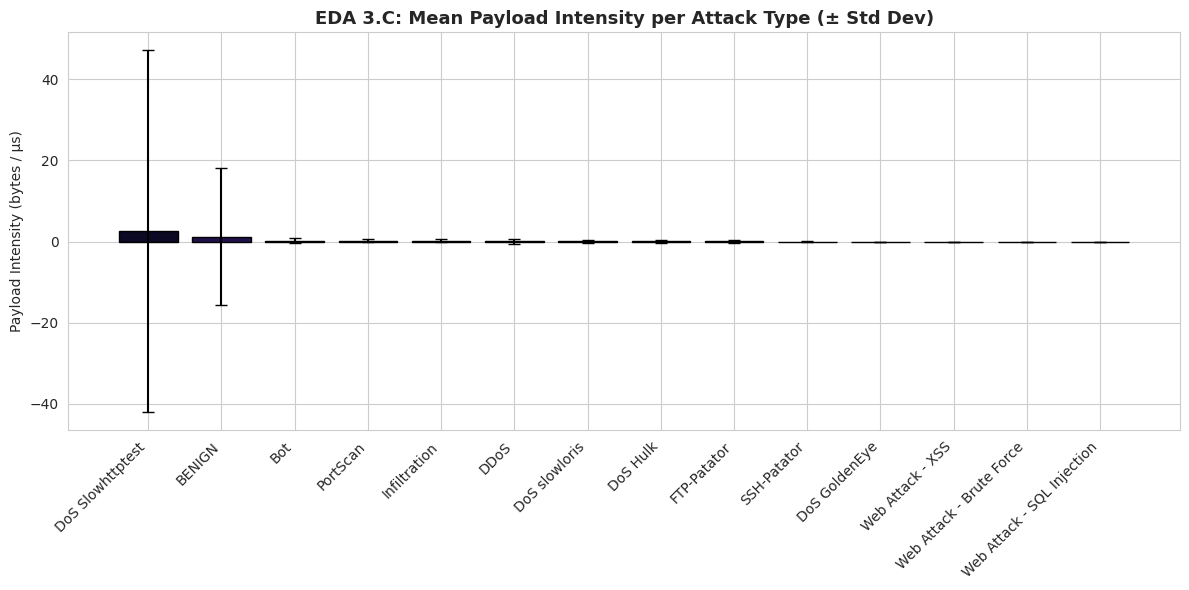

In [ ]:
# EDA 3.C: Bar Chart - Mean Payload Intensity per Attack Type
# Higher payload_intensity in DDoS/DoS should be clearly visible here
plt.figure(figsize=(12, 6))
intensity_by_label = viz_sample.groupby('label')['payload_intensity'] \
    .agg(['mean', 'std']).reset_index().sort_values('mean', ascending=False)

bars = plt.bar(intensity_by_label['label'], intensity_by_label['mean'],
               yerr=intensity_by_label['std'], capsize=4,
               color=sns.color_palette('magma', len(intensity_by_label)),
               edgecolor='black')
plt.title('EDA 3.C: Mean Payload Intensity per Attack Type (± Std Dev)',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Payload Intensity (bytes / μs)')
plt.tight_layout()
plt.show()

In [ ]:
# EDA 3.D: Scatter Plot - fwd_bwd_packet_ratio vs payload_intensity
# Reveals 2D separation between Benign and attack types in the engineered space
scatter_sample = viz_sample.copy()
scatter_sample['fwd_bwd_packet_ratio'] = scatter_sample['fwd_bwd_packet_ratio'].clip(upper=50)
scatter_sample['payload_intensity'] = scatter_sample['payload_intensity'].clip(upper=scatter_sample['payload_intensity'].quantile(0.99))

fig = px.scatter(
    scatter_sample.sample(3000, random_state=42),
    x='fwd_bwd_packet_ratio',
    y='payload_intensity',
    color='label',
    title='EDA 3.D: fwd_bwd_packet_ratio vs payload_intensity (Engineered Feature Space)',
    opacity=0.6,
    color_discrete_sequence=px.colors.qualitative.Bold
)
fig.update_layout(legend_title_text='Traffic Class')
fig.show()

In [ ]:
# Step 3.4: Sanitizing Engineered Features
# Re-checking for any nulls or infinities created during the ratio calculations
from pyspark.sql.functions import col, when

engineered_cols = [
    "fwd_bwd_packet_ratio", "fwd_bwd_byte_ratio",
    "packet_size_variability", "active_idle_ratio",
    "payload_intensity", "total_flow_intensity"
]

for c in engineered_cols:
    df_extracted = df_extracted.withColumn(
        c, when(col(c).isin(float('inf'), float('-inf')), None).otherwise(col(c))
    )

before_san = df_extracted.count()
df_extracted = df_extracted.na.drop(subset=engineered_cols)
after_san = df_extracted.count()

print(f"Records removed during engineered feature sanitization: {before_san - after_san:,}")
print(f"Final record count after feature engineering: {after_san:,}")

Records removed during engineered feature sanitization: 0
Final record count after feature engineering: 2,520,691


---

### **Step 4: Feature Selection & Dimensionality Reduction**
> **Assigned to:** *Ahmed Nassar*

In this stage, we identify the most relevant attributes to reduce model complexity and improve training speed. We combine statistical correlation analysis with machine learning-based importance to eliminate redundant and non-predictive features.

*   **Task:** Apply Correlation Matrix and Hybrid Feature Importance (Random Forest + LightGBM).
*   **Requirements:** Identify multicollinearity and rank features by predictive power.
*   **Objective:** Optimize the feature set for high-performance distributed training.

---

#### **4.1 Statistical Filter: Correlation Analysis**

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd
import plotly.express as px

# 1. Identify numeric columns for correlation analysis
numeric_features = [col_name for col_name, col_type in df_extracted.dtypes
                    if col_type in ('int', 'double', 'long', 'float') and col_name != 'label']

print(f"Number of numeric features for correlation analysis: {len(numeric_features)}")

# 2. Assemble features into a single vector (Required for Spark Correlation computation)
assembler_corr = VectorAssembler(inputCols=numeric_features, outputCol="corr_features_vector")
df_vector = assembler_corr.transform(df_extracted)

# 3. Compute Pearson Correlation Matrix
r = Correlation.corr(df_vector, "corr_features_vector").head()
correlation_matrix = r[0].toArray()

# 4. Convert to Pandas for visualization
correlation_df = pd.DataFrame(correlation_matrix, columns=numeric_features, index=numeric_features)
print("Correlation matrix computed successfully.")

Number of numeric features for correlation analysis: 74
Correlation matrix computed successfully.


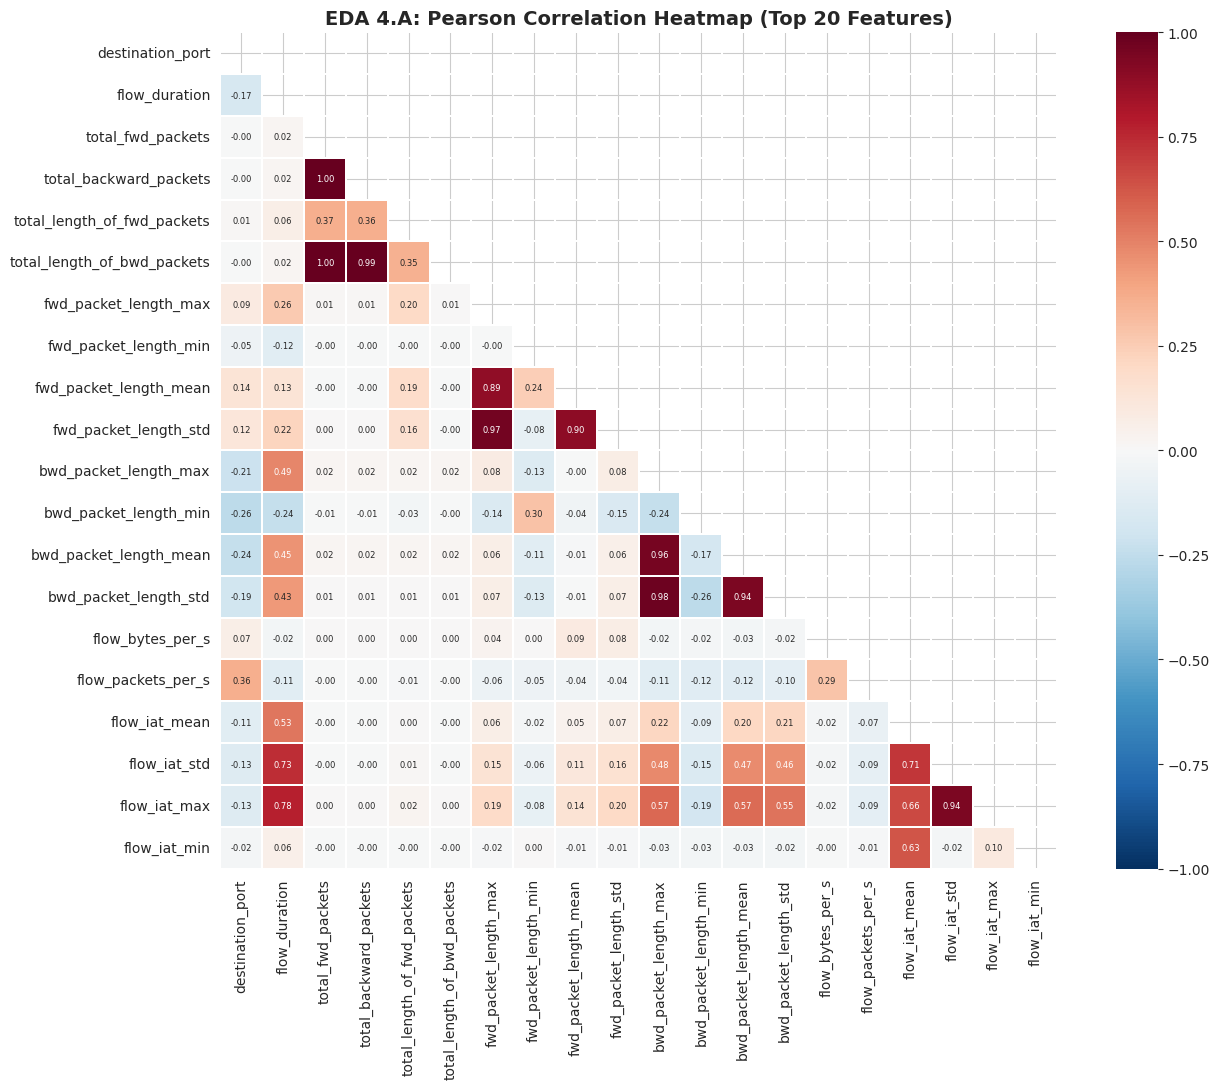

In [ ]:
# EDA 4.A: Correlation Heatmap (Top 20 features for readability)
# Features with high correlation share redundant information
top20_features = numeric_features[:20]
corr_top20 = correlation_df.loc[top20_features, top20_features]

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_top20, dtype=bool))  # Show only lower triangle
sns.heatmap(
    corr_top20,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.3,
    annot_kws={"size": 6}
)
plt.title('EDA 4.A: Pearson Correlation Heatmap (Top 20 Features)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Identify highly correlated feature pairs (|correlation| > 0.9)
# These pairs are candidates for removal to reduce multicollinearity
high_corr_threshold = 0.9
highly_correlated_pairs = set()

for i in range(len(numeric_features)):
    for j in range(i + 1, len(numeric_features)):
        if abs(correlation_df.iloc[i, j]) > high_corr_threshold:
            pair = tuple(sorted((numeric_features[i], numeric_features[j])))
            highly_correlated_pairs.add(pair)

print(f"Highly correlated pairs (|r| > {high_corr_threshold}): {len(highly_correlated_pairs)}")
print("Sample pairs:")
for p in list(highly_correlated_pairs)[:5]:
    print(f"  {p[0]} <-> {p[1]}  (r = {correlation_df.loc[p[0], p[1]]:.3f})")

Highly correlated pairs (|r| > 0.9): 73
Sample pairs:
  fwd_psh_flags <-> syn_flag_count  (r = 1.000)
  bwd_packet_length_max <-> packet_length_std  (r = 0.939)
  idle_max <-> idle_min  (r = 0.961)
  total_fwd_packets <-> total_length_of_bwd_packets  (r = 0.997)
  average_packet_size <-> max_packet_length  (r = 0.912)


In [ ]:
# EDA 4.B: Interactive Full Correlation Heatmap (Plotly)
# Allows zooming and hovering for detailed inspection of all feature pairs
fig = px.imshow(
    correlation_df,
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='EDA 4.B: Interactive Full Feature Correlation Matrix',
    aspect="auto"
)
fig.update_layout(width=900, height=800)
fig.show()

#### **4.2 ML Filter: Hybrid Feature Importance (RF & LightGBM)**

In [ ]:
# Install the optimized native LightGBM library
!pip install lightgbm -q

In [ ]:
import lightgbm as lgb
from pyspark.ml.feature import StringIndexer, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.classification import RandomForestClassifier

# Build the preprocessing pipeline: encode labels, assemble and scale features
indexer   = StringIndexer(inputCol="label", outputCol="indexedLabel", handleInvalid="skip")
assembler = VectorAssembler(inputCols=numeric_features, outputCol="rawFeatures")
scaler    = StandardScaler(inputCol="rawFeatures", outputCol="features",
                           withStd=True, withMean=False)

selection_pipeline = Pipeline(stages=[indexer, assembler, scaler])
pipeline_model     = selection_pipeline.fit(df_extracted)
df_ml              = pipeline_model.transform(df_extracted)

print("Preprocessing pipeline fitted and data transformed.")
print(f"Number of classes: {pipeline_model.stages[0].labels}")

Preprocessing pipeline fitted and data transformed.
Number of classes: ['BENIGN', 'DoS Hulk', 'DDoS', 'PortScan', 'DoS GoldenEye', 'FTP-Patator', 'DoS slowloris', 'DoS Slowhttptest', 'SSH-Patator', 'Bot', 'Web Attack - Brute Force', 'Web Attack - XSS', 'Infiltration', 'Web Attack - SQL Injection', 'Heartbleed']


In [ ]:
# Train Random Forest on a subset for feature importance extraction
# numTrees=50 gives stable importance scores without excessive compute time
print("Training Random Forest for feature importance...")
t0 = time.time()
rf = RandomForestClassifier(labelCol="indexedLabel", featuresCol="features",
                             numTrees=50, seed=42)
rf_model       = rf.fit(df_ml)
rf_importance  = rf_model.featureImportances.toArray()
print(f"Random Forest trained in {time.time()-t0:.1f}s")

Training Random Forest for feature importance...
Random Forest trained in 506.2s


In [ ]:
# Extract LightGBM Feature Importance (Native Python - runs on a sampled Pandas subset)
# This avoids JVM/Python serialization overhead of SynapseML for importance extraction only
import numpy as np
import lightgbm as lgb

# Sample 20% of data to keep Pandas conversion feasible
pdf_sample = df_ml.select("features", "indexedLabel").sample(0.2, seed=42).toPandas()

# Reshape Spark DenseVectors into a 2D NumPy matrix
X_matrix = np.stack(pdf_sample['features'].apply(lambda x: x.toArray()).values)
X_lgb    = pd.DataFrame(X_matrix, columns=numeric_features)
y_lgb    = pdf_sample['indexedLabel']

lgb_data   = lgb.Dataset(X_lgb, label=y_lgb)
lgb_params = {
    'objective' : 'multiclass',
    'num_class' : int(y_lgb.max() + 1),
    'verbosity' : -1,
    'seed'      : 42
}

print("Training Native LightGBM to extract feature importance...")
lgb_native       = lgb.train(lgb_params, lgb_data, num_boost_round=100)
lgbm_importance  = lgb_native.feature_importance(importance_type='gain')
lgbm_importance  = lgbm_importance / lgbm_importance.sum()   # Normalize to [0, 1]

print(f"LightGBM importance extracted. Data shape: {X_lgb.shape}")

Training Native LightGBM to extract feature importance...
LightGBM importance extracted. Data shape: (503149, 74)


In [ ]:
# Consolidate Hybrid Importance Score (average of RF and LightGBM)
# Consensus between two different model families provides a robust ranking
importance_df = pd.DataFrame({
    'Feature'        : numeric_features,
    'RF_Score'       : rf_importance,
    'LGBM_Score'     : lgbm_importance,
    'Combined_Score' : (rf_importance + lgbm_importance) / 2
}).sort_values(by='Combined_Score', ascending=False)

print("Top 15 Features by Hybrid Importance Score:")
display(importance_df.head(15).reset_index(drop=True))

Top 15 Features by Hybrid Importance Score:


,Feature,RF_Score,LGBM_Score,Combined_Score
0,fwd_packet_length_min,0.001697,0.227411,0.114554
1,flow_bytes_per_s,0.017772,0.128219,0.072996
2,bwd_packet_length_std,0.091211,0.001611,0.046411
3,packet_length_variance,0.086244,0.000051,0.043148
4,fwd_packet_length_max,0.041467,0.042047,0.041757
5,fwd_bwd_byte_ratio,0.010517,0.068575,0.039546
6,bwd_iat_min,0.000056,0.075609,0.037832
7,bwd_packet_length_mean,0.070415,0.001573,0.035994
8,total_length_of_fwd_packets,0.042134,0.024744,0.033439
9,payload_intensity,0.006616,0.054659,0.030637


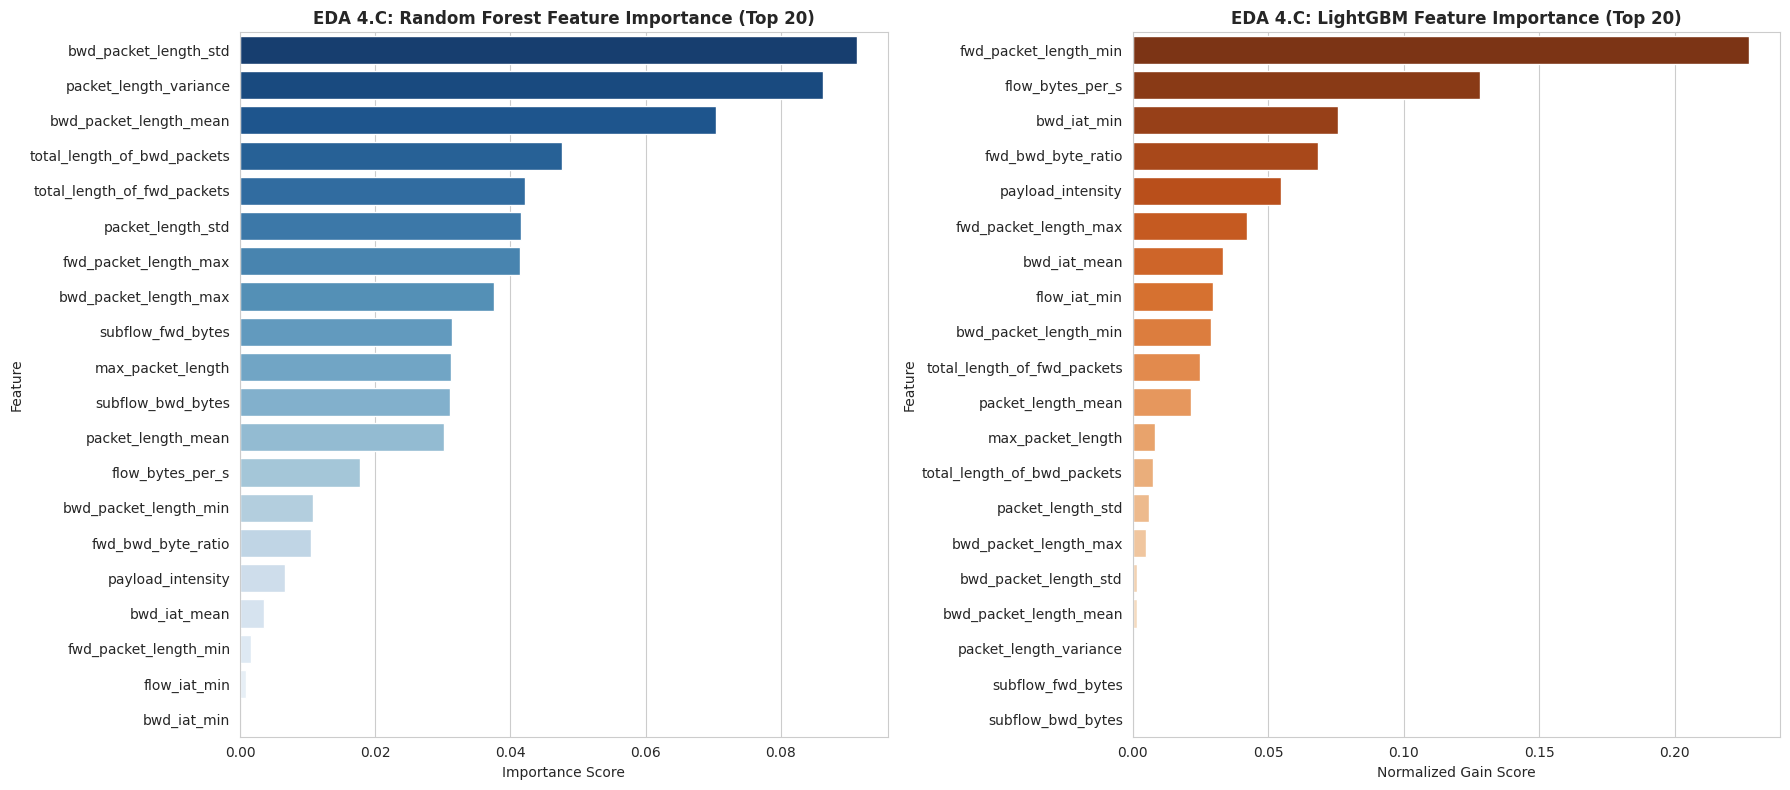

In [ ]:
# EDA 4.C: Side-by-side comparison of RF vs LightGBM feature importance
# Highlights where the two models agree and disagree on feature ranking
top_n = 20
top_features_df = importance_df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# RF importance
sns.barplot(x='RF_Score', y='Feature',
            data=top_features_df.sort_values('RF_Score', ascending=False),
            palette='Blues_r', ax=axes[0])
axes[0].set_title('EDA 4.C: Random Forest Feature Importance (Top 20)',
                  fontweight='bold')
axes[0].set_xlabel('Importance Score')

# LightGBM importance
sns.barplot(x='LGBM_Score', y='Feature',
            data=top_features_df.sort_values('LGBM_Score', ascending=False),
            palette='Oranges_r', ax=axes[1])
axes[1].set_title('EDA 4.C: LightGBM Feature Importance (Top 20)',
                  fontweight='bold')
axes[1].set_xlabel('Normalized Gain Score')

plt.tight_layout()
plt.show()

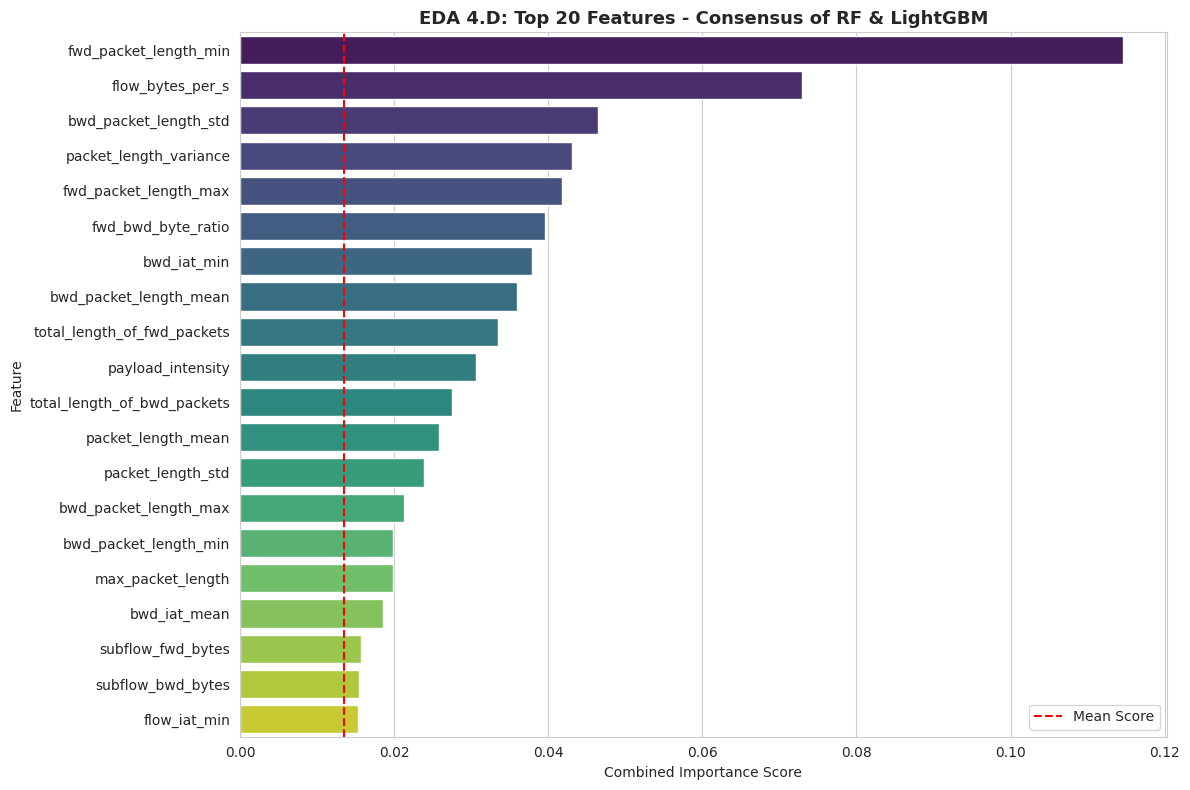

In [ ]:
# EDA 4.D: Hybrid Combined Score - Final Top 20
plt.figure(figsize=(12, 8))
sns.barplot(x='Combined_Score', y='Feature',
            data=importance_df.head(20), palette='viridis')
plt.axvline(x=importance_df['Combined_Score'].mean(), color='red',
            linestyle='--', label='Mean Score')
plt.legend()
plt.title('EDA 4.D: Top 20 Features - Consensus of RF & LightGBM',
          fontsize=13, fontweight='bold')
plt.xlabel('Combined Importance Score')
plt.tight_layout()
plt.show()

#### **4.3 Feature Selection Execution**

In [ ]:
# Drop zero-importance features and redundant correlated features
# For correlated pairs, we keep the feature with the higher combined importance score
importance_map  = importance_df.set_index('Feature')['Combined_Score'].to_dict()
features_to_drop = set(importance_df[importance_df['Combined_Score'] == 0]['Feature'])

for f1, f2 in highly_correlated_pairs:
    if importance_map.get(f1, 0) >= importance_map.get(f2, 0):
        features_to_drop.add(f2)
    else:
        features_to_drop.add(f1)

# Finalize selection - ensure the label column is always preserved
selected_features = [f for f in df_extracted.columns if f not in features_to_drop]
if 'label' not in selected_features:
    selected_features.append('label')

df_preprocessed = df_extracted.select(*selected_features)

n_original = len(numeric_features)
n_selected = len(selected_features) - 1  # Exclude label column
print(f"Features before selection: {n_original}")
print(f"Features after selection : {n_selected}")
print(f"Dimensionality reduction  : {(1 - n_selected/n_original)*100:.1f}%")

Features before selection: 74
Features after selection : 44
Dimensionality reduction  : 40.5%


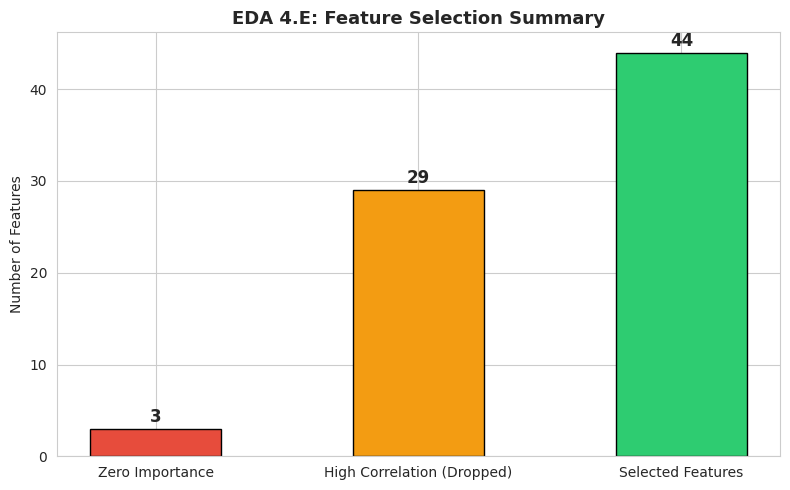

In [ ]:
# EDA 4.E: Feature Reduction Summary
# Visual summary of the selection process
categories = ['Zero Importance', 'High Correlation (Dropped)', 'Selected Features']
n_zero_imp = len(importance_df[importance_df['Combined_Score'] == 0])
n_corr_drop = len(features_to_drop) - n_zero_imp
values = [n_zero_imp, n_corr_drop, n_selected]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax.bar(categories, values, color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_title('EDA 4.E: Feature Selection Summary', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Features')
plt.tight_layout()
plt.show()

#### **4.4 Export Metadata & Save Data**

In [ ]:
# Export Label Mapping for Deployment Config
labels_list   = pipeline_model.stages[0].labels
label_mapping = {label: float(i) for i, label in enumerate(labels_list)}
print("Deployment Label Mapping:")
for k, v in label_mapping.items():
    print(f"  {v:.0f} -> {k}")

Deployment Label Mapping:
  0 -> BENIGN
  1 -> DoS Hulk
  2 -> DDoS
  3 -> PortScan
  4 -> DoS GoldenEye
  5 -> FTP-Patator
  6 -> DoS slowloris
  7 -> DoS Slowhttptest
  8 -> SSH-Patator
  9 -> Bot
  10 -> Web Attack - Brute Force
  11 -> Web Attack - XSS
  12 -> Infiltration
  13 -> Web Attack - SQL Injection
  14 -> Heartbleed


In [ ]:

# Build the final column list: selected features (no label) + label
non_label_selected = [f for f in selected_features if f.lower().strip() != 'label']

# Verify 'label' exists in df_extracted before selecting
label_col_in_extracted = next(
    (c for c in df_extracted.columns if c.lower().strip() == 'label'), None
)
if label_col_in_extracted is None:
    raise ValueError("'label' column not found in df_extracted. Check previous steps.")

# Select final features + label in one clean operation — no join, no duplicates
final_cols = non_label_selected + [label_col_in_extracted]
df_final_to_save = df_extracted.select(*final_cols)

# Standardize label column name to lowercase 'label'
if label_col_in_extracted != 'label':
    df_final_to_save = df_final_to_save.withColumnRenamed(label_col_in_extracted, 'label')

output_path_selected = "/content/drive/MyDrive/AML_BD_DS_Project/df_selected.parquet"
df_final_to_save.write.mode("overwrite").parquet(output_path_selected)

print(f"Selected features saved to : {output_path_selected}")
print(f"Total Columns              : {len(df_final_to_save.columns)} ({len(non_label_selected)} features + 'label')")
print(f"Total Records              : {df_final_to_save.count():,}")
print(f"Columns                    : {df_final_to_save.columns}")

Selected features saved to : /content/drive/MyDrive/AML_BD_DS_Project/df_selected.parquet
Total Columns              : 45 (44 features + 'label')
Total Records              : 2,520,691
Columns                    : ['destination_port', 'total_length_of_fwd_packets', 'total_length_of_bwd_packets', 'fwd_packet_length_max', 'fwd_packet_length_min', 'fwd_packet_length_mean', 'bwd_packet_length_min', 'bwd_packet_length_std', 'flow_bytes_per_s', 'flow_iat_mean', 'flow_iat_min', 'fwd_iat_total', 'fwd_iat_max', 'fwd_iat_min', 'bwd_iat_total', 'bwd_iat_std', 'bwd_iat_max', 'bwd_iat_min', 'fwd_urg_flags', 'fwd_header_length34', 'bwd_header_length', 'fwd_packets_per_s', 'bwd_packets_per_s', 'min_packet_length', 'packet_length_variance', 'fin_flag_count', 'syn_flag_count', 'psh_flag_count', 'ack_flag_count', 'urg_flag_count', 'down_per_up_ratio', 'fwd_header_length55', 'init_win_bytes_forward', 'init_win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'active_std', 'active_max', 'activ

---
### **Step 5: Data Imbalance Handling & Scaling**
> **Assigned to:** *Ahd Sayed Atia*

In network security datasets, attack classes are significantly underrepresented compared to benign traffic. This step addresses class imbalance to ensure the model doesn't become biased toward the majority class.

*   **Task:** Apply balancing techniques (Under-sampling, Over-sampling, and Combined) and evaluate their impact.
*   **Requirements:** Statistical evidence of distribution before and after balancing.
*   **Outcome:** A highly balanced dataset ready for the final production model.
---

#### **5.1 Loading data and preparing the graphical environment**

In [ ]:
df_preprocessed = spark.read.parquet(
    "/content/drive/MyDrive/AML_BD_DS_Project/df_selected.parquet"
)
print(f"Data loaded: {df_preprocessed.count():,} records | "
      f"{len(df_preprocessed.columns)} columns")

plt.rcParams.update({
    "figure.facecolor": "#0d1117", "axes.facecolor": "#161b22",
    "axes.edgecolor":   "#30363d", "text.color":     "#FFFFFF",
    "xtick.color":      "#FFFFFF", "ytick.color":    "#FFFFFF",
    "grid.alpha": 0.3
})
BG_DARK   = "#0d1117"
BG_BORDER = "#30363d"
SEED      = 42


Data loaded: 2,520,691 records | 45 columns


#### **5.2 Label Encoding & Normalization**

In [ ]:
# Step 5.2.1: Robust Label Encoding
# Handles common variations: 'Label', 'label', 'labels', ' label' (with spaces)
potential_label_cols = [c for c in df_preprocessed.columns
                        if c.lower().strip() in ['label', 'labels', 'class']]

if not potential_label_cols:
    raise ValueError(f"No Label column found. Available: {df_preprocessed.columns}")

actual_label_col = potential_label_cols[0]
print(f"Found Label column: '{actual_label_col}'")

df_preprocessed = df_preprocessed.withColumnRenamed(actual_label_col, "Label")

# Apply StringIndexer: maps string labels to float indices (0.0, 1.0, 2.0, ...)
indexer       = StringIndexer(inputCol="Label", outputCol="indexedLabel", handleInvalid="skip")
indexer_model = indexer.fit(df_preprocessed)
df_encoded    = indexer_model.transform(df_preprocessed)

print("\nLabel Encoding complete. Index -> Label mapping:")
df_encoded.select("Label", "indexedLabel").distinct().sort("indexedLabel").show()

label_mapping = {lbl: float(i) for i, lbl in enumerate(indexer_model.labels)}
print(f"Label mapping: {label_mapping}")

Found Label column: 'label'

Label Encoding complete. Index -> Label mapping:
+--------------------+------------+
|               Label|indexedLabel|
+--------------------+------------+
|              BENIGN|         0.0|
|            DoS Hulk|         1.0|
|                DDoS|         2.0|
|            PortScan|         3.0|
|       DoS GoldenEye|         4.0|
|         FTP-Patator|         5.0|
|       DoS slowloris|         6.0|
|    DoS Slowhttptest|         7.0|
|         SSH-Patator|         8.0|
|                 Bot|         9.0|
|Web Attack - Brut...|        10.0|
|    Web Attack - XSS|        11.0|
|        Infiltration|        12.0|
|Web Attack - SQL ...|        13.0|
|          Heartbleed|        14.0|
+--------------------+------------+

Label mapping: {'BENIGN': 0.0, 'DoS Hulk': 1.0, 'DDoS': 2.0, 'PortScan': 3.0, 'DoS GoldenEye': 4.0, 'FTP-Patator': 5.0, 'DoS slowloris': 6.0, 'DoS Slowhttptest': 7.0, 'SSH-Patator': 8.0, 'Bot': 9.0, 'Web Attack - Brute Force': 10.0, 'Web

In [ ]:
# Step 5.2.2: Vectorization & Standardization
# StandardScaler ensures all features contribute equally regardless of their original units
feature_cols = [c for c in df_encoded.columns if c not in ["Label", "indexedLabel"]]

assembler  = VectorAssembler(inputCols=feature_cols, outputCol="rawFeatures")
scaler     = StandardScaler(inputCol="rawFeatures", outputCol="features",
                            withStd=True, withMean=False)

prep_pipeline = Pipeline(stages=[assembler, scaler])
prep_model    = prep_pipeline.fit(df_encoded)
df_ready      = prep_model.transform(df_encoded).select("Label", "indexedLabel", "features")

# Save models for deployment
indexer_model.write().overwrite().save("/content/drive/MyDrive/AML_BD_DS_Project/label_indexer_model")
prep_model.write().overwrite().save("/content/drive/MyDrive/AML_BD_DS_Project/preprocessing_pipeline_model")

df_ready.cache()
print("Preprocessing complete. Pipeline models saved.")

Preprocessing complete. Pipeline models saved.


#### **5.3 Imbalance Analysis (Statistical Evidence Before Balancing)**

In [ ]:
class_dist_before = (df_ready
                     .groupBy("Label").count()
                     .orderBy(F.desc("count"))
                     .toPandas())
total_records = df_ready.count()
class_dist_before["pct"] = (
    class_dist_before["count"] / total_records * 100
).round(3)

print("═" * 60)
print("CLASS DISTRIBUTION — BEFORE BALANCING")
print("═" * 60)
print(class_dist_before.to_string(index=False))
imbalance_ratio = (class_dist_before["count"].max() /
                   class_dist_before["count"].min())
print(f"\nImbalance Ratio: {imbalance_ratio:,.0f} : 1")


════════════════════════════════════════════════════════════
CLASS DISTRIBUTION — BEFORE BALANCING
════════════════════════════════════════════════════════════
                     Label   count    pct
                    BENIGN 2094950 83.110
                  DoS Hulk  172846  6.857
                      DDoS  128014  5.079
                  PortScan   90694  3.598
             DoS GoldenEye   10286  0.408
               FTP-Patator    5931  0.235
             DoS slowloris    5385  0.214
          DoS Slowhttptest    5228  0.207
               SSH-Patator    3219  0.128
                       Bot    1948  0.077
  Web Attack - Brute Force    1470  0.058
          Web Attack - XSS     652  0.026
              Infiltration      36  0.001
Web Attack - SQL Injection      21  0.001
                Heartbleed      11  0.000

Imbalance Ratio: 190,450 : 1


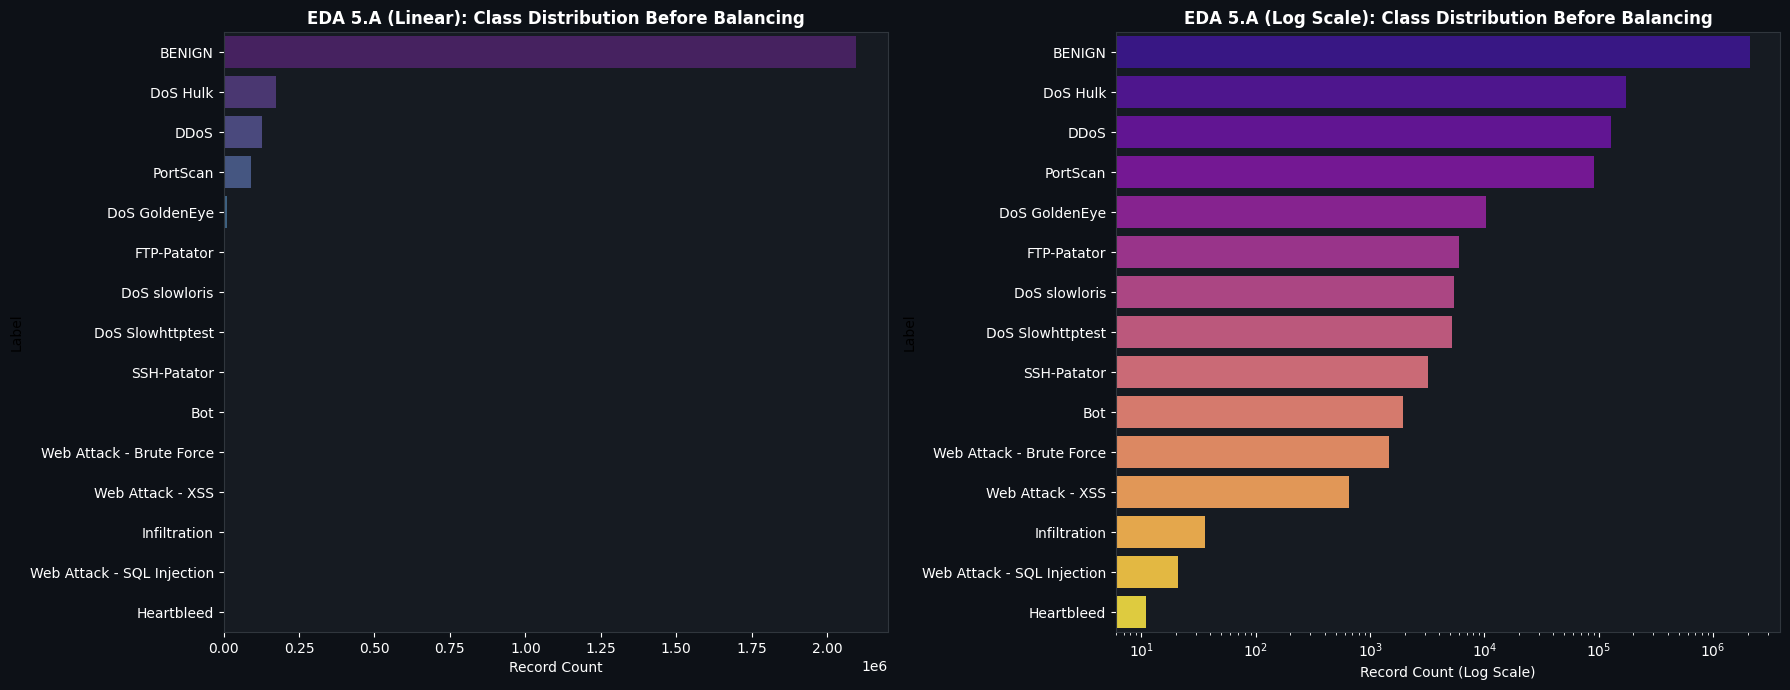

In [ ]:
# EDA 5.A: Class Distribution Before Balancing
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x="count", y="Label", data=class_dist_before,
            palette="viridis", hue="Label", legend=False, ax=axes[0])
axes[0].set_title("EDA 5.A (Linear): Class Distribution Before Balancing",
                  color="white", fontweight="bold")
axes[0].set_xlabel("Record Count", color="white")

sns.barplot(x="count", y="Label", data=class_dist_before,
            palette="plasma", hue="Label", legend=False, ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("EDA 5.A (Log Scale): Class Distribution Before Balancing",
                  color="white", fontweight="bold")
axes[1].set_xlabel("Record Count (Log Scale)", color="white")

plt.tight_layout()
plt.show()

#### **5.4 Implementing Balancing Strategies**

In [ ]:
from functools import reduce

# Strategy A: Random Under-Sampling
# Reduces majority classes - fast but loses information
target_under = int(class_dist_before["count"].quantile(0.75))
target_under = max(target_under, 1000)   # minimum 1000 per class

under_parts = []
for lbl in class_dist_before["Label"]:
    df_cls   = df_ready.filter(F.col("Label") == lbl)
    n        = df_cls.count()
    fraction = min(target_under / n, 1.0)
    under_parts.append(df_cls.sample(False, fraction, seed=SEED))

df_under  = reduce(lambda a, b: a.union(b), under_parts).cache()
n_under   = df_under.count()
print(f"[Strategy A] Under-Sampling target : {target_under:,} per class")
print(f"[Strategy A] Total records         : {n_under:,}")


[Strategy A] Under-Sampling target : 50,490 per class
[Strategy A] Total records         : 236,446


In [ ]:
# Strategy B: Random Over-Sampling
# Replicates minority class rows - preserves data but risks overfitting
target_over_base = int(class_dist_before["count"].quantile(0.60))

over_parts = []
for lbl in class_dist_before["Label"]:
    df_cls = df_ready.filter(F.col("Label") == lbl)
    n      = df_cls.count()

    max_target = min(target_over_base, n * 20)
    target     = max(max_target, n)
    fraction   = target / n
    with_rep   = fraction > 1.0

    over_parts.append(df_cls.sample(with_rep, fraction, seed=SEED))

df_over  = reduce(lambda a, b: a.union(b), over_parts).cache()
n_over   = df_over.count()
print(f"[Strategy B] Over-Sampling base target : {target_over_base:,}")
print(f"[Strategy B] Total records             : {n_over:,}")

[Strategy B] Over-Sampling base target : 5,603
[Strategy B] Total records             : 2,537,487


In [ ]:
from functools import reduce
from pyspark.ml.linalg import Vectors

# STRATEGY C — Tiered Hybrid (5-Tier + SMOTE for MICRO classes)
# Tiers minimize the inter-class gap:
#   LARGE  (> 50K)    -> under-sample to 30,000
#   MEDIUM (5K-50K)   -> cap         at  5,000
#   SMALL  (1K-5K)    -> over-sample to  5,000  # Increased target to ensure oversampling
#   TINY   (100-1K)   -> over-sample to  2,000  # New tier and target
#   MICRO  (< 100)    -> Spark SMOTE  to  1,000  # Increased target
TIER_LARGE_TARGET  = 30_000
TIER_MEDIUM_TARGET =  5_000
TIER_SMALL_TARGET  =  5_000 # Adjusted
TIER_TINY_TARGET   =  2_000 # Added
TIER_MICRO_TARGET  =  1_000 # Adjusted

def spark_smote(df_cls, target_n, k=3, seed=42):
    """
    Spark-native SMOTE for MICRO classes.
    Works directly on the features DenseVector — no raw columns needed.
    Steps: extract vectors -> find K neighbors -> interpolate -> rebuild DataFrame.
    """
    import random
    import numpy as np
    import pandas as pd

    # Collect to pandas — safe because MICRO classes have < 100 rows
    pdf = df_cls.toPandas()
    n_orig = len(pdf)

    if n_orig < 2:
        return df_cls.sample(True, target_n / n_orig, seed=seed)

    # Extract feature values from DenseVector
    feature_matrix = np.array([v.toArray() for v in pdf["features"]])
    n_synthetic    = target_n - n_orig
    synthetic_vecs = []

    random.seed(seed)
    np.random.seed(seed)

    for _ in range(n_synthetic):
        idx      = random.randint(0, n_orig - 1)
        sample   = feature_matrix[idx]

        # Find K nearest neighbors by Euclidean distance
        dists    = np.linalg.norm(feature_matrix - sample, axis=1)
        dists[idx] = np.inf
        k_actual = min(k, n_orig - 1)
        neighbors = np.argsort(dists)[:k_actual]

        # Interpolate between sample and a random neighbor
        neighbor = feature_matrix[random.choice(neighbors)]
        alpha    = random.random()
        synthetic_vecs.append(sample + alpha * (neighbor - sample))

    # Build synthetic rows with same Label/indexedLabel
    lbl_val = pdf["Label"].iloc[0]
    idx_val = pdf["indexedLabel"].iloc[0]
    synthetic_rows = [
        (lbl_val, float(idx_val), Vectors.dense(vec.tolist()))
        for vec in synthetic_vecs
    ]

    # Create Spark DataFrame from synthetic rows and union with original
    synthetic_df = df_cls.sparkSession.createDataFrame(
        synthetic_rows,
        schema=df_cls.schema
    )
    return df_cls.union(synthetic_df)


print("\n[Strategy C] Tiered Hybrid (5-Tier + SMOTE) — Class Assignment:")
hybrid_parts = []
for _, row in class_dist_before.iterrows():
    lbl = row["Label"]
    n   = int(row["count"])
    df_cls = df_ready.filter(F.col("Label") == lbl)

    if n > 50_000:
        tier_name = "LARGE  -> Under"
        target    = TIER_LARGE_TARGET
        fraction  = target / n
        hybrid_parts.append(df_cls.sample(False, fraction, seed=SEED))
    elif n >= 5_000:
        tier_name = "MEDIUM -> Cap"
        target    = min(n, TIER_MEDIUM_TARGET)
        fraction  = target / n
        hybrid_parts.append(df_cls.sample(False, fraction, seed=SEED))
    elif n >= 1_000: # Small tier for over-sampling
        tier_name = "SMALL  -> Over"
        target    = TIER_SMALL_TARGET # Ensures actual over-sampling
        fraction  = target / n
        hybrid_parts.append(df_cls.sample(True, fraction, seed=SEED))
    elif n >= 100: # Tiny tier for over-sampling (e.g., Web Attack - XSS)
        tier_name = "TINY   -> Over"
        target    = TIER_TINY_TARGET # New target
        fraction  = target / n
        hybrid_parts.append(df_cls.sample(True, fraction, seed=SEED))
    else: # Micro tier for SMOTE (n < 100)
        tier_name = "MICRO  -> SMOTE"
        target    = TIER_MICRO_TARGET # New target
        hybrid_parts.append(spark_smote(df_cls, target, k=5, seed=SEED)) # k increased to 5

    print(f"  [{tier_name:18s}] {lbl:35s} {n:>8,} -> {target:>7,}")

df_hybrid = reduce(lambda a, b: a.union(b), hybrid_parts).cache()
n_hybrid  = df_hybrid.count()
print(f"\n[Strategy C] Total records : {n_hybrid:,}")
print("[Strategy C] SMOTE applied to MICRO classes (Infiltration, SQL Injection, Heartbleed)")


[Strategy C] Tiered Hybrid (5-Tier + SMOTE) — Class Assignment:
  [LARGE  -> Under   ] BENIGN                              2,094,950 ->  30,000
  [LARGE  -> Under   ] DoS Hulk                             172,846 ->  30,000
  [LARGE  -> Under   ] DDoS                                 128,014 ->  30,000
  [LARGE  -> Under   ] PortScan                              90,694 ->  30,000
  [MEDIUM -> Cap     ] DoS GoldenEye                         10,286 ->   5,000
  [MEDIUM -> Cap     ] FTP-Patator                            5,931 ->   5,000
  [MEDIUM -> Cap     ] DoS slowloris                          5,385 ->   5,000
  [MEDIUM -> Cap     ] DoS Slowhttptest                       5,228 ->   5,000
  [SMALL  -> Over    ] SSH-Patator                            3,219 ->   5,000
  [SMALL  -> Over    ] Bot                                    1,948 ->   5,000
  [SMALL  -> Over    ] Web Attack - Brute Force               1,470 ->   5,000
  [TINY   -> Over    ] Web Attack - XSS                         6

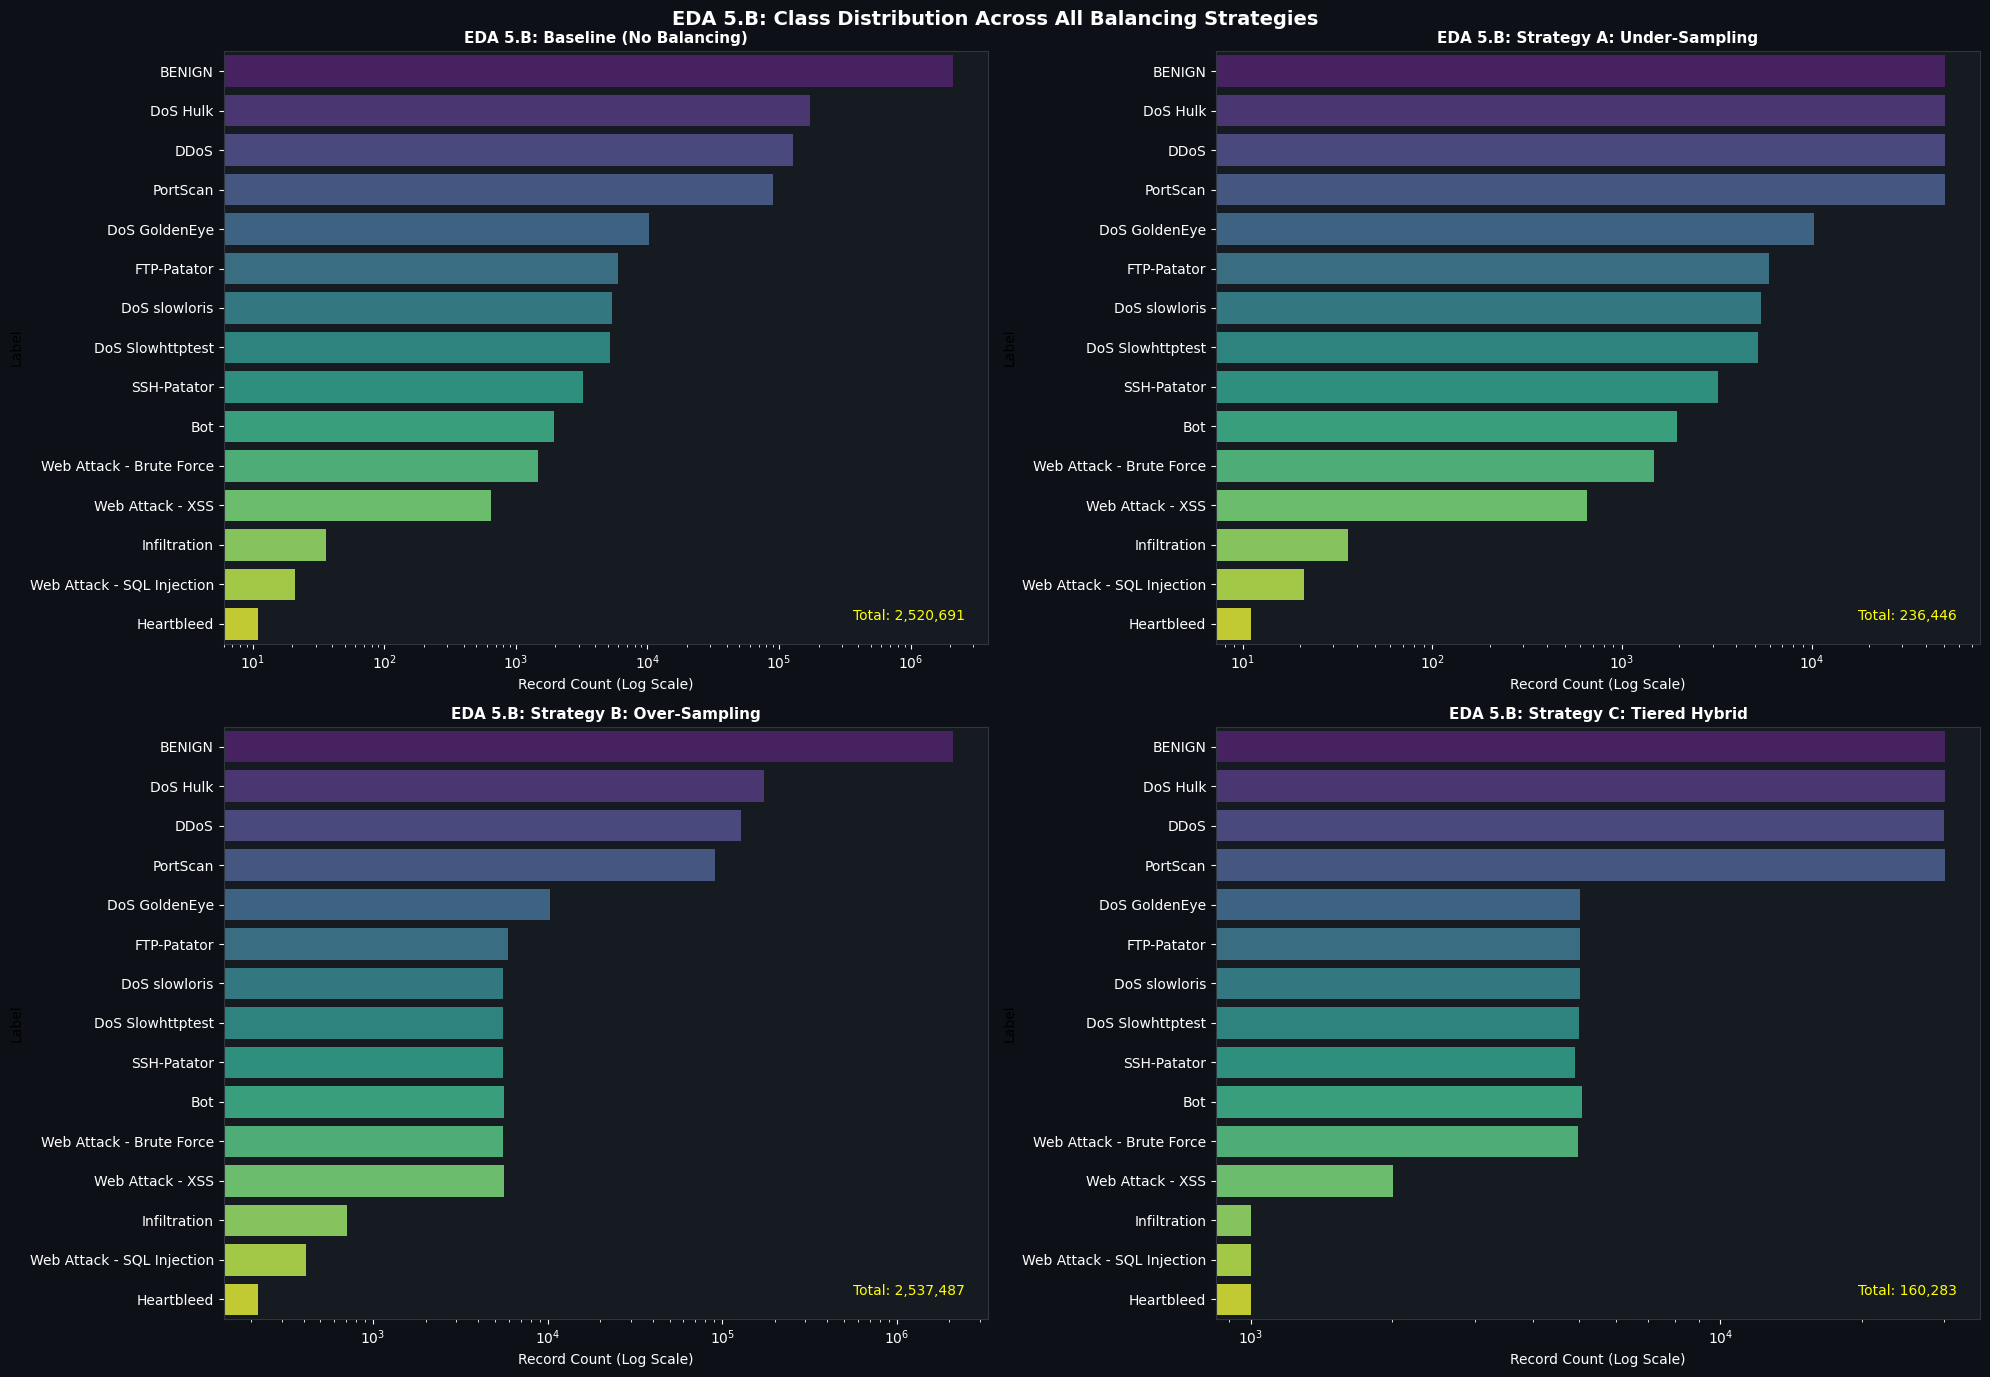

Saved: viz_5B_all_strategies.png


In [ ]:
#EDA:Distribution after imbalance handling
fixed_order_raw = (df_ready.groupBy("Label").count()
                   .orderBy(F.desc("count")).toPandas())
fixed_order = fixed_order_raw.sort_values("count", ascending=False)["Label"].tolist()

def get_class_dist(df_spark, name):
    dist = (df_spark.groupBy("Label").count()
            .orderBy(F.desc("count")).toPandas())
    dist["Strategy"] = name
    dist["Label"] = pd.Categorical(dist["Label"], categories=fixed_order, ordered=True)
    return dist.sort_values("Label")

dist_baseline = get_class_dist(df_ready,  "Baseline")
dist_under    = get_class_dist(df_under,  "Under-Sampling")
dist_over     = get_class_dist(df_over,   "Over-Sampling")
dist_hybrid   = get_class_dist(df_hybrid, "Tiered Hybrid")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))
for ax, (dist, title, total) in zip(
    axes.flatten(),
    [
        (dist_baseline, "Baseline (No Balancing)",    total_records),
        (dist_under,    "Strategy A: Under-Sampling", n_under),
        (dist_over,     "Strategy B: Over-Sampling",  n_over),
        (dist_hybrid,   "Strategy C: Tiered Hybrid",  n_hybrid),
    ]
):
    sns.barplot(x="count", y="Label", data=dist,
                palette="viridis", hue="Label", legend=False, ax=ax)
    ax.set_xscale("log")
    ax.set_title(f"EDA 5.B: {title}", color="white",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel("Record Count (Log Scale)", color="white")
    ax.text(0.97, 0.04, f"Total: {total:,}",
            transform=ax.transAxes, ha="right",
            color="yellow", fontsize=10)

plt.suptitle("EDA 5.B: Class Distribution Across All Balancing Strategies",
             fontsize=14, color="white", fontweight="bold")
plt.tight_layout()
plt.savefig("viz_5B_all_strategies.png", dpi=150,
            bbox_inches="tight", facecolor=BG_DARK)
plt.show()
print("Saved: viz_5B_all_strategies.png")

#### **5.5 Evaluate Strategies & Select the Winning Method**

In [ ]:
import time
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Load and prepare holdout test set
df_test_raw_holdout = spark.read.parquet(
    "/content/drive/MyDrive/AML_BD_DS_Project/df_test_holdout.parquet"
)
df_test_raw_holdout = df_test_raw_holdout \
    .withColumn("fwd_bwd_packet_ratio",
                F.when(F.col("total_backward_packets") == 0, 0.0)
                .otherwise(F.col("total_fwd_packets") / F.col("total_backward_packets"))) \
    .withColumn("fwd_bwd_byte_ratio",
                F.when(F.col("total_length_of_bwd_packets") == 0, 0.0)
                .otherwise(F.col("total_length_of_fwd_packets") / F.col("total_length_of_bwd_packets"))) \
    .withColumn("packet_size_variability",
                F.when(F.col("min_packet_length") == 0, 0.0)
                .otherwise(F.col("max_packet_length") / F.col("min_packet_length"))) \
    .withColumn("active_idle_ratio",
                F.when(F.col("idle_mean") == 0, 0.0)
                .otherwise(F.col("active_mean") / F.col("idle_mean"))) \
    .withColumn("payload_intensity",
                (F.col("total_length_of_fwd_packets") + F.col("total_length_of_bwd_packets"))
                / (F.col("flow_duration") + 1)) \
    .withColumn("total_flow_intensity",
                (F.col("total_fwd_packets") + F.col("total_backward_packets"))
                / (F.col("flow_duration") + 1))

_lbl = next((c for c in df_test_raw_holdout.columns if c.lower() == "label"), None)
if _lbl and _lbl != "Label":
    df_test_raw_holdout = df_test_raw_holdout.withColumnRenamed(_lbl, "Label")

df_test_holdout_encoded = indexer_model.transform(df_test_raw_holdout)
df_test_holdout_ready   = prep_model.transform(df_test_holdout_encoded).select(
    "Label", "indexedLabel", "features"
)
df_test_holdout_ready.cache()
print(f"Holdout test set ready: {df_test_holdout_ready.count():,} records")

def diagnostic_eval(df_spark, name, n_trees=30):
    """Trains a diagnostic RF model and evaluates on the true holdout test set."""
    print(f"\nEvaluating strategy: {name}")
    t0 = time.time()

    rf_eval = RandomForestClassifier(
        labelCol="indexedLabel", featuresCol="features", numTrees=n_trees, seed=SEED
    )
    rf_model_eval = rf_eval.fit(df_spark)
    preds = rf_model_eval.transform(df_test_holdout_ready)

    evaluator = MulticlassClassificationEvaluator(labelCol="indexedLabel")

    pred_pd = preds.select("indexedLabel", "prediction").toPandas()
    per_class_f1s = []
    for cls in sorted(pred_pd["indexedLabel"].unique()):
        tp = int(((pred_pd["prediction"] == cls) & (pred_pd["indexedLabel"] == cls)).sum())
        fp = int(((pred_pd["prediction"] == cls) & (pred_pd["indexedLabel"] != cls)).sum())
        fn = int(((pred_pd["prediction"] != cls) & (pred_pd["indexedLabel"] == cls)).sum())
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        per_class_f1s.append(f1)
    macro_f1 = sum(per_class_f1s) / len(per_class_f1s)

    return {
        "method"     : name,
        "df"         : df_spark,
        "predictions": preds,
        "f1"         : evaluator.setMetricName("f1").evaluate(preds),
        "macro_f1"   : round(macro_f1, 4),
        "accuracy"   : evaluator.setMetricName("accuracy").evaluate(preds),
        "precision"  : evaluator.setMetricName("weightedPrecision").evaluate(preds),
        "recall"     : evaluator.setMetricName("weightedRecall").evaluate(preds),
        "time_s"     : round(time.time() - t0, 1),
    }

results = [
    diagnostic_eval(df_ready,  "Baseline (No Balance)"),
    diagnostic_eval(df_under,  "A: Under-Sampling"),
    diagnostic_eval(df_over,   "B: Over-Sampling"),
    diagnostic_eval(df_hybrid, "C: Tiered Hybrid"),
]

results_df = pd.DataFrame(results).round(4)
print("\n" + "═" * 60)
print("BALANCING STRATEGIES EVALUATION (Diagnostic RF)")
print("═" * 60)
display(results_df.drop(columns=["df", "predictions"]))

best = max(results, key=lambda x: x["macro_f1"])
print(f"\nWinning strategy: {best['method']} with Macro F1 = {best['macro_f1']}")

strategy_colors = {
    "Baseline (No Balance)" : "#888888",
    "A: Under-Sampling"     : "#3498db",
    "B: Over-Sampling"      : "#e74c3c",
    "C: Tiered Hybrid"      : "#2ecc71",
}
bar_colors = [strategy_colors.get(r["method"], "#888") for r in results]

Holdout test set ready: 504,133 records

Evaluating strategy: Baseline (No Balance)

Evaluating strategy: A: Under-Sampling

Evaluating strategy: B: Over-Sampling

Evaluating strategy: C: Tiered Hybrid

════════════════════════════════════════════════════════════
BALANCING STRATEGIES EVALUATION (Diagnostic RF)
════════════════════════════════════════════════════════════


,method,f1,macro_f1,accuracy,precision,recall,time_s
0,Baseline (No Balance),0.9735,0.3035,0.9787,0.9697,0.9787,171.6
1,A: Under-Sampling,0.9818,0.5572,0.9820,0.9827,0.9820,75.0
2,B: Over-Sampling,0.9746,0.3711,0.9798,0.9708,0.9798,185.2
3,C: Tiered Hybrid,0.9663,0.6352,0.9569,0.9788,0.9569,68.0



Winning strategy: C: Tiered Hybrid with Macro F1 = 0.6352


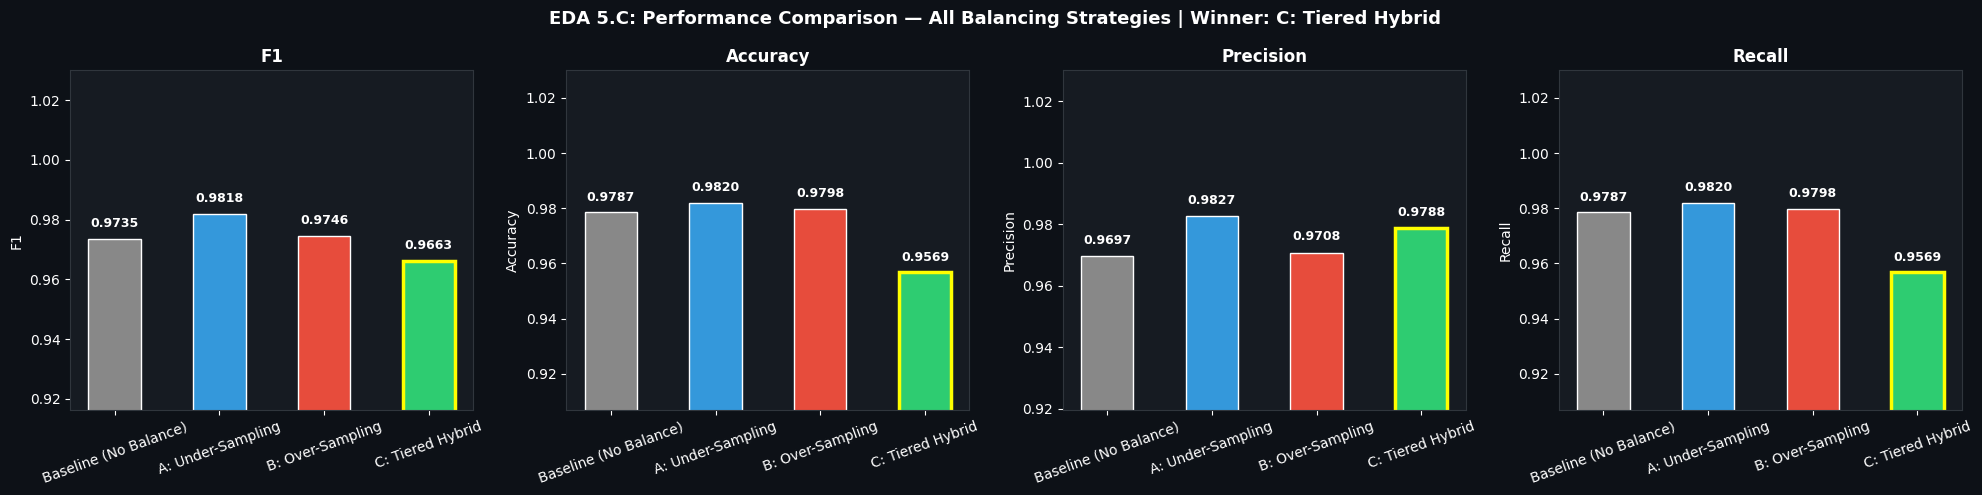

Saved: viz_5C_performance.png


In [ ]:
#— Performance Comparison Chart
strategy_colors = {
    "Baseline (No Balance)" : "#888888",
    "A: Under-Sampling"     : "#3498db",
    "B: Over-Sampling"      : "#e74c3c",
    "C: Tiered Hybrid"      : "#2ecc71",
}
bar_colors = [strategy_colors.get(r["method"], "#888")
              for r in results]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, metric in zip(axes, ["f1", "accuracy", "precision", "recall"]):
    vals = results_df[metric].values
    bars = ax.bar(results_df["method"], vals,
                  color=bar_colors, edgecolor="white", width=0.5)
    ax.set_ylim(max(0, min(vals) - 0.05), 1.03)
    ax.set_title(metric.replace("_", " ").title(), color="white", fontweight="bold") # Convert to Title Case
    ax.set_ylabel(metric.replace("_", " ").title(), color="white")
    ax.tick_params(axis="x", rotation=20, colors="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f"{val:.4f}", ha="center", va="bottom",
                fontsize=9, color="white", fontweight="bold")

# Highlight the winner
winner_name = best["method"]
for ax in axes:
    for bar, label in zip(ax.patches, results_df["method"]):
        if label == winner_name:
            bar.set_edgecolor("yellow")
            bar.set_linewidth(2.5)

plt.suptitle("EDA 5.C: Performance Comparison — All Balancing Strategies "
             f"| Winner: {winner_name}",
             fontsize=13, color="white", fontweight="bold")
plt.tight_layout()
plt.savefig("viz_5C_performance.png", dpi=150,
            bbox_inches="tight", facecolor=BG_DARK)
plt.show()
print("Saved: viz_5C_performance.png")

Computing per-class F1 for all strategies...


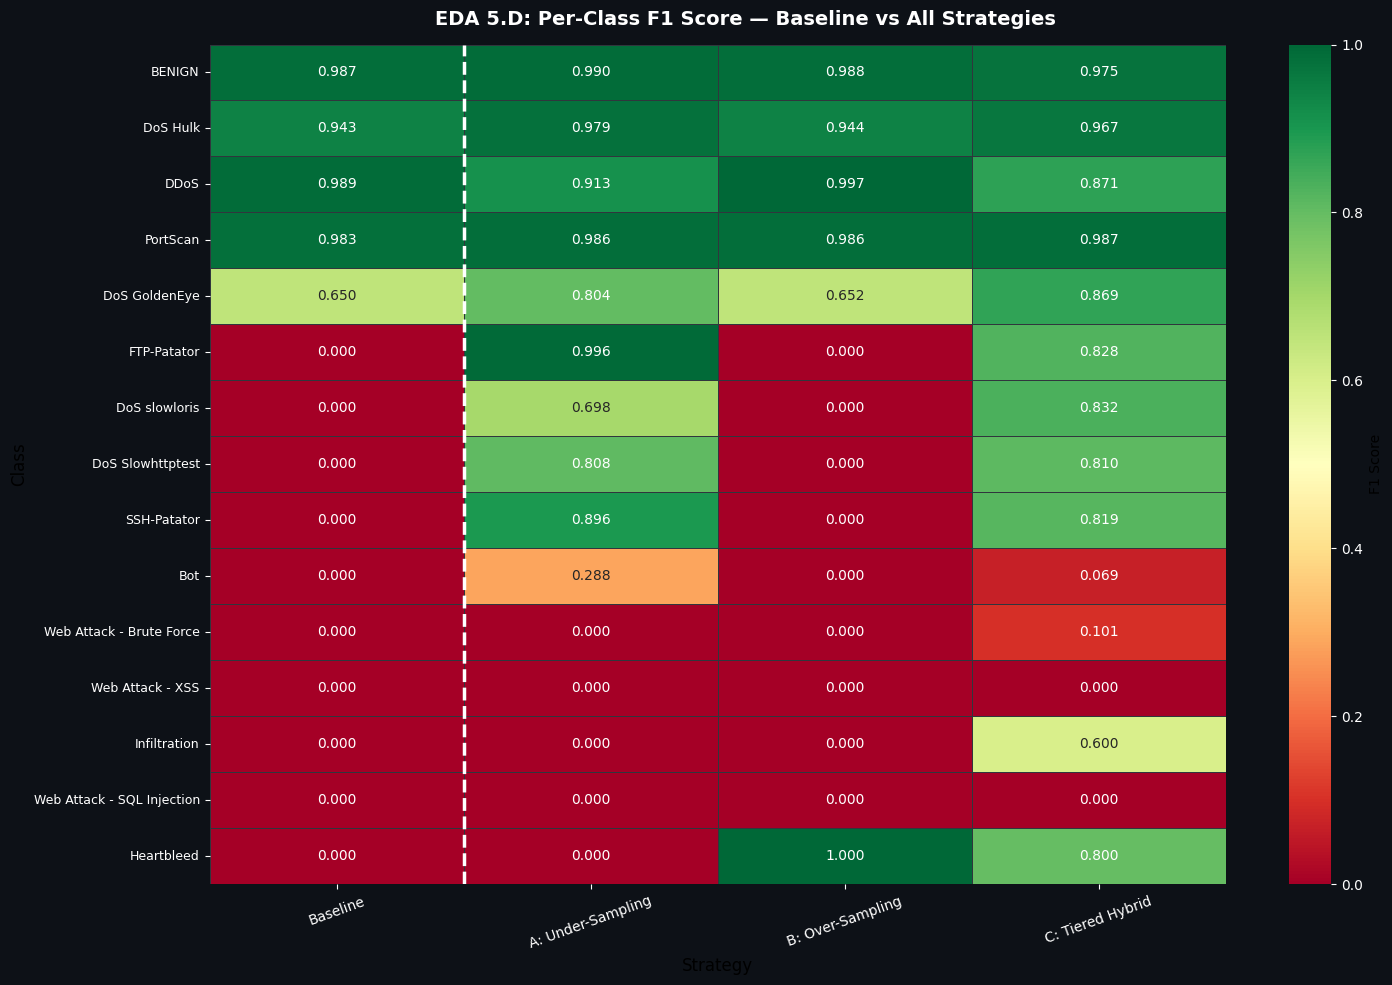

Saved: viz_5D_perclass_heatmap.png


In [ ]:
# Map index → label string (derived from indexer_model)
index_to_label_map = {float(i): lbl for i, lbl in enumerate(indexer_model.labels)}

# Per-Class F1 Heatmap
def per_class_f1_dict(predictions_spark):
    pred_pd = predictions_spark.select("indexedLabel", "prediction").toPandas()
    out = {}
    for cls in sorted(pred_pd["indexedLabel"].unique()):
        tp = int(((pred_pd["prediction"] == cls) &
                  (pred_pd["indexedLabel"] == cls)).sum())
        fp = int(((pred_pd["prediction"] == cls) &
                  (pred_pd["indexedLabel"] != cls)).sum())
        fn = int(((pred_pd["prediction"] != cls) &
                  (pred_pd["indexedLabel"] == cls)).sum())
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
        lbl = index_to_label_map.get(cls, f"cls_{cls}")
        out[lbl] = round(f1, 4)
    return out

print("Computing per-class F1 for all strategies...")
f1_baseline = per_class_f1_dict(results[0]["predictions"])
f1_under    = per_class_f1_dict(results[1]["predictions"])
f1_over     = per_class_f1_dict(results[2]["predictions"])
f1_hybrid   = per_class_f1_dict(results[3]["predictions"])

all_labels = list(label_mapping.keys())
heatmap_df = pd.DataFrame({
    "Baseline"          : [f1_baseline.get(l, 0) for l in all_labels],
    "A: Under-Sampling" : [f1_under.get(l,   0) for l in all_labels],
    "B: Over-Sampling"  : [f1_over.get(l,    0) for l in all_labels],
    "C: Tiered Hybrid"  : [f1_hybrid.get(l,  0) for l in all_labels],
}, index=all_labels)

fig, ax = plt.subplots(figsize=(15, 10))
fig.suptitle("EDA 5.D: Per-Class F1 Score — Baseline vs All Strategies",
             fontsize=14, fontweight="bold")
sns.heatmap(
    heatmap_df, annot=True, fmt=".3f", cmap="RdYlGn",
    linewidths=0.5, linecolor=BG_BORDER,
    cbar_kws={"label": "F1 Score"},
    ax=ax, vmin=0, vmax=1
)
# Highlight the Baseline column with a thicker separator line
ax.axvline(x=1, color="white", linewidth=2.5, linestyle="--")
ax.set_xlabel("Strategy", fontsize=12)
ax.set_ylabel("Class",    fontsize=12)
ax.tick_params(axis="x", rotation=20, labelsize=10)
ax.tick_params(axis="y", rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig("viz_5D_perclass_heatmap.png", dpi=150,
            bbox_inches="tight", facecolor=BG_DARK)
plt.show()
print("Saved: viz_5D_perclass_heatmap.png")

In [ ]:
#  Save Best Dataset
balanced_path = "/content/drive/MyDrive/AML_BD_DS_Project/df_balanced_best.parquet"

best["df"].write.mode("overwrite").parquet(balanced_path)

n_best = best["df"].count()
print(f"\nBest balanced dataset saved → {balanced_path}")
print(f"   Strategy : {best['method']}")
print(f"   Records  : {n_best:,}")
print(f"   F1 Score : {best['f1']:.4f}")

# Final summary
print("\n" + "═" * 60)
print("STEP 5 COMPLETE — SUMMARY")
print("═" * 60)
print(f"  Original records   : {total_records:,}")
print(f"  Original imbalance : {imbalance_ratio:,.0f} : 1")
print()
for r in results:
    marker = " ← WINNER" if r["method"] == best["method"] else ""
    print(f"  {r['method']:25s} | F1: {r['f1']:.4f} | "
          f"Acc: {r['accuracy']:.4f}{marker}")
print()
print(f"  Saved as           : df_balanced_best.parquet")
print("═" * 60)


Best balanced dataset saved → /content/drive/MyDrive/AML_BD_DS_Project/df_balanced_best.parquet
   Strategy : C: Tiered Hybrid
   Records  : 160,283
   F1 Score : 0.9663

════════════════════════════════════════════════════════════
STEP 5 COMPLETE — SUMMARY
════════════════════════════════════════════════════════════
  Original records   : 2,520,691
  Original imbalance : 190,450 : 1

  Baseline (No Balance)     | F1: 0.9735 | Acc: 0.9787
  A: Under-Sampling         | F1: 0.9818 | Acc: 0.9820
  B: Over-Sampling          | F1: 0.9746 | Acc: 0.9798
  C: Tiered Hybrid          | F1: 0.9663 | Acc: 0.9569 ← WINNER

  Saved as           : df_balanced_best.parquet
════════════════════════════════════════════════════════════


---
### **Step 6: Model Training & Evaluation (Applied ML)**
> **Assigned to:** *Reem Ahmed Maher*

The core of our intelligent system where we train the detection model.
* **Task:** Split the data into Training and Testing sets using **Spark MLlib**.
* **Requirements:** Train robust classifiers (Random Forest & LightGBM) to detect malicious activities.
* **Objective:** Evaluate the model using Confusion Matrix, Precision, Recall, and F1-Score.

---


#### **6.1 Optimized Train/Test Split &Data Loading & Environment Setup**

In [ ]:
SEED = 42

from pyspark.ml.feature import StringIndexerModel
from pyspark.ml         import PipelineModel

# Load saved models from Step 5
indexer_model_step6 = StringIndexerModel.load(
    "/content/drive/MyDrive/AML_BD_DS_Project/label_indexer_model"
)
prep_model_step6 = PipelineModel.load(
    "/content/drive/MyDrive/AML_BD_DS_Project/preprocessing_pipeline_model"
)

# ─────────────────────────────────────────────────────────────
# Cell 6.2: Load the TRUE holdout test set (saved in Step 2)
# and apply engineered features before the pipeline
# Anti-leakage: df_test_holdout was never seen during training
# ─────────────────────────────────────────────────────────────
df_test_raw = spark.read.parquet(
    "/content/drive/MyDrive/AML_BD_DS_Project/df_test_holdout.parquet"
)

# Apply the SAME feature engineering as Step 3
# This is NOT data leakage — purely mathematical transformations
df_test_raw = df_test_raw \
    .withColumn("fwd_bwd_packet_ratio",
                F.when(F.col("total_backward_packets") == 0, 0.0)
                .otherwise(F.col("total_fwd_packets") / F.col("total_backward_packets"))) \
    .withColumn("fwd_bwd_byte_ratio",
                F.when(F.col("total_length_of_bwd_packets") == 0, 0.0)
                .otherwise(F.col("total_length_of_fwd_packets") / F.col("total_length_of_bwd_packets"))) \
    .withColumn("packet_size_variability",
                F.when(F.col("min_packet_length") == 0, 0.0)
                .otherwise(F.col("max_packet_length") / F.col("min_packet_length"))) \
    .withColumn("active_idle_ratio",
                F.when(F.col("idle_mean") == 0, 0.0)
                .otherwise(F.col("active_mean") / F.col("idle_mean"))) \
    .withColumn("payload_intensity",
                (F.col("total_length_of_fwd_packets") + F.col("total_length_of_bwd_packets"))
                / (F.col("flow_duration") + 1)) \
    .withColumn("total_flow_intensity",
                (F.col("total_fwd_packets") + F.col("total_backward_packets"))
                / (F.col("flow_duration") + 1))

# Sanitize: remove Inf values introduced by ratio calculations
for _c in ["fwd_bwd_packet_ratio", "fwd_bwd_byte_ratio", "packet_size_variability",
           "active_idle_ratio", "payload_intensity", "total_flow_intensity"]:
    df_test_raw = df_test_raw.withColumn(
        _c, F.when(F.col(_c).isin(float('inf'), float('-inf')), None).otherwise(F.col(_c))
    )
df_test_raw = df_test_raw.na.drop()

# Standardize label column name
_lbl_col = next((c for c in df_test_raw.columns if c.lower().strip() in ['label', 'labels']), None)
if _lbl_col and _lbl_col != "Label":
    df_test_raw = df_test_raw.withColumnRenamed(_lbl_col, "Label")

# Encode labels and apply preprocessing pipeline
df_test_encoded = indexer_model_step6.transform(df_test_raw)
df_test_final   = prep_model_step6.transform(df_test_encoded).select(
    "features", "indexedLabel"
)
df_test_final.cache()

# ─────────────────────────────────────────────────────────────
# Training data = best balanced dataset from Step 5
# ─────────────────────────────────────────────────────────────
df_best  = spark.read.parquet(
    "/content/drive/MyDrive/AML_BD_DS_Project/df_balanced_best.parquet"
)
train_df = df_best.select("features", "indexedLabel").repartition(20)
test_df  = df_test_final
train_df.cache()

n_train = train_df.count()
n_test  = test_df.count()
print(f"Training Set : {n_train:,} records (balanced — from Step 5 best strategy)")
print(f"Testing Set  : {n_test:,} records  (true holdout — never seen during training)")

# Decode labels for display
index_to_label = {float(i): lbl for i, lbl in enumerate(indexer_model_step6.labels)}
n_classes = len(index_to_label)

# Class distribution sanity check
print("\nClass distribution in Test Set:")
test_dist = (df_test_final
             .groupBy("indexedLabel").count()
             .orderBy("indexedLabel")
             .toPandas())
test_dist["Label"] = test_dist["indexedLabel"].map(index_to_label)
print(test_dist[["Label", "count"]].to_string(index=False))
print(f"\nClasses represented in test set: {len(test_dist)} / {n_classes}")


Training Set : 160,283 records (balanced — from Step 5 best strategy)
Testing Set  : 504,133 records  (true holdout — never seen during training)

Class distribution in Test Set:
                     Label  count
                    BENIGN 418990
                  DoS Hulk  34569
                      DDoS  25602
                  PortScan  18138
             DoS GoldenEye   2057
               FTP-Patator   1186
             DoS slowloris   1077
          DoS Slowhttptest   1045
               SSH-Patator    643
                       Bot    389
  Web Attack - Brute Force    294
          Web Attack - XSS    130
              Infiltration      7
Web Attack - SQL Injection      4
                Heartbleed      2

Classes represented in test set: 15 / 15


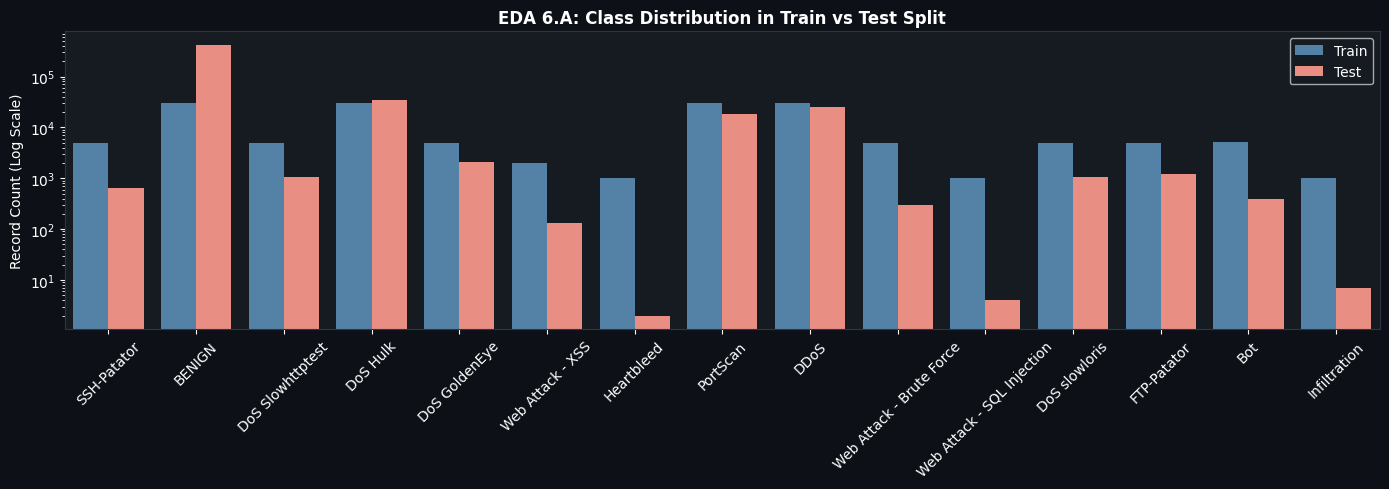

In [ ]:
# EDA 6.A: Verify Class Distribution in Train and Test Splits
# Ensures the split did not accidentally introduce class imbalance
train_dist = train_df.groupBy("indexedLabel").count().toPandas()
train_dist['Label'] = train_dist['indexedLabel'].map(index_to_label)
train_dist['Split'] = 'Train'

test_dist = test_df.groupBy("indexedLabel").count().toPandas()
test_dist['Label'] = test_dist['indexedLabel'].map(index_to_label)
test_dist['Split'] = 'Test'

split_dist = pd.concat([train_dist, test_dist])

plt.figure(figsize=(14, 5), facecolor='#0d1117')
ax = sns.barplot(x='Label', y='count', hue='Split',
                 data=split_dist, palette=['steelblue', 'salmon'])
ax.set_yscale('log')
ax.set_title('EDA 6.A: Class Distribution in Train vs Test Split',
             color='white', fontweight='bold')
ax.tick_params(axis='x', rotation=45, colors='white')
ax.set_ylabel('Record Count (Log Scale)', color='white')
ax.set_xlabel('')
plt.legend(facecolor='#161b22', labelcolor='white')
plt.tight_layout()
plt.show()

#### **6.2 Model 1: Random Forest (Spark MLlib)**

In [ ]:
# Random Forest with Cross-Validated Hyperparameter Tuning
# Grid search over numTrees and maxDepth to find the optimal configuration
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

print("Starting Random Forest Cross-Validation...")
rf = RandomForestClassifier(labelCol="indexedLabel", featuresCol="features", seed=SEED)

paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [100, 150]) \
    .addGrid(rf.maxDepth, [10, 15]) \
    .build()

cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=MulticlassClassificationEvaluator(labelCol="indexedLabel", metricName="f1"),
    numFolds=3,
    parallelism=2
)

t0      = time.time()
cv_model = cv.fit(train_df)
rf_best  = cv_model.bestModel
rf_time  = time.time() - t0

print(f"RF Cross-Validation complete in {rf_time:.1f}s")
print(f"Best numTrees: {rf_best.getNumTrees}")
print(f"Best maxDepth: {rf_best.getMaxDepth()}")

# Save model
rf_best.write().overwrite().save("/content/drive/MyDrive/AML_BD_DS_Project/rf_best_model")
print("Random Forest model saved.")

Starting Random Forest Cross-Validation...
RF Cross-Validation complete in 3921.9s
Best numTrees: 100
Best maxDepth: 15
Random Forest model saved.


#### **6.3 Model 2: LightGBM (Native Implementation)**

In [ ]:
import joblib
# LightGBM trained using the native Python library for Streamlit deployment compatibility
# The Spark-based SynapseML LightGBM produces Spark-only models (.load() required)
# Native .pkl format allows direct loading in any Python environment
import lightgbm as lgb
import numpy as np

def spark_to_numpy(sdf):
    """Convert a Spark DataFrame with 'features' DenseVector to a NumPy matrix."""
    data = sdf.collect()
    X = np.array([row["features"].toArray() for row in data])
    y = np.array([int(row["indexedLabel"]) for row in data])
    return X, y

print("Converting Spark DataFrames to NumPy arrays...")
X_train, y_train = spark_to_numpy(train_df)
X_test,  y_test  = spark_to_numpy(test_df)
print(f"X_train shape: {X_train.shape}  |  X_test shape: {X_test.shape}")

lgbm_clf = lgb.LGBMClassifier(
    n_estimators   = 200,
    learning_rate  = 0.1,
    num_leaves     = 63,
    objective      = 'multiclass',
    random_state   = SEED,
    n_jobs         = -1,
    force_row_wise = True,   # Suppresses the overhead warning
    verbose        = -1      # Silences all [Info]/[Warning] output
)

t0 = time.time()
lgbm_clf.fit(X_train, y_train)
lgbm_time = time.time() - t0

print(f"LightGBM trained in {lgbm_time:.1f}s")

# Save as .pkl for Streamlit deployment
joblib.dump(lgbm_clf, "/content/drive/MyDrive/AML_BD_DS_Project/lgbm_best_model.pkl")
print("LightGBM model saved as .pkl for Streamlit deployment.")

Converting Spark DataFrames to NumPy arrays...
X_train shape: (160283, 44)  |  X_test shape: (504133, 44)
LightGBM trained in 106.6s
LightGBM model saved as .pkl for Streamlit deployment.


#### **6.4 Comprehensive Evaluation & Comparison**

In [ ]:
# Generate predictions and compute full classification report for LightGBM
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

y_pred_lgbm  = lgbm_clf.predict(X_test)
y_proba_lgbm = lgbm_clf.predict_proba(X_test)
class_names  = [index_to_label[i] for i in sorted(index_to_label.keys())]
n_classes    = len(class_names)

print("LightGBM - Full Classification Report:")
print(classification_report(y_test, y_pred_lgbm, target_names=class_names))

LightGBM - Full Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    418990
                  DoS Hulk       1.00      1.00      1.00     34569
                      DDoS       1.00      1.00      1.00     25602
                  PortScan       0.99      1.00      0.99     18138
             DoS GoldenEye       0.99      1.00      1.00      2057
               FTP-Patator       0.99      1.00      1.00      1186
             DoS slowloris       0.99      1.00      0.99      1077
          DoS Slowhttptest       0.97      1.00      0.98      1045
               SSH-Patator       0.98      1.00      0.99       643
                       Bot       0.65      1.00      0.79       389
  Web Attack - Brute Force       0.96      0.99      0.97       294
          Web Attack - XSS       0.86      0.95      0.90       130
              Infiltration       0.70      1.00      0.82         7
Web Atta

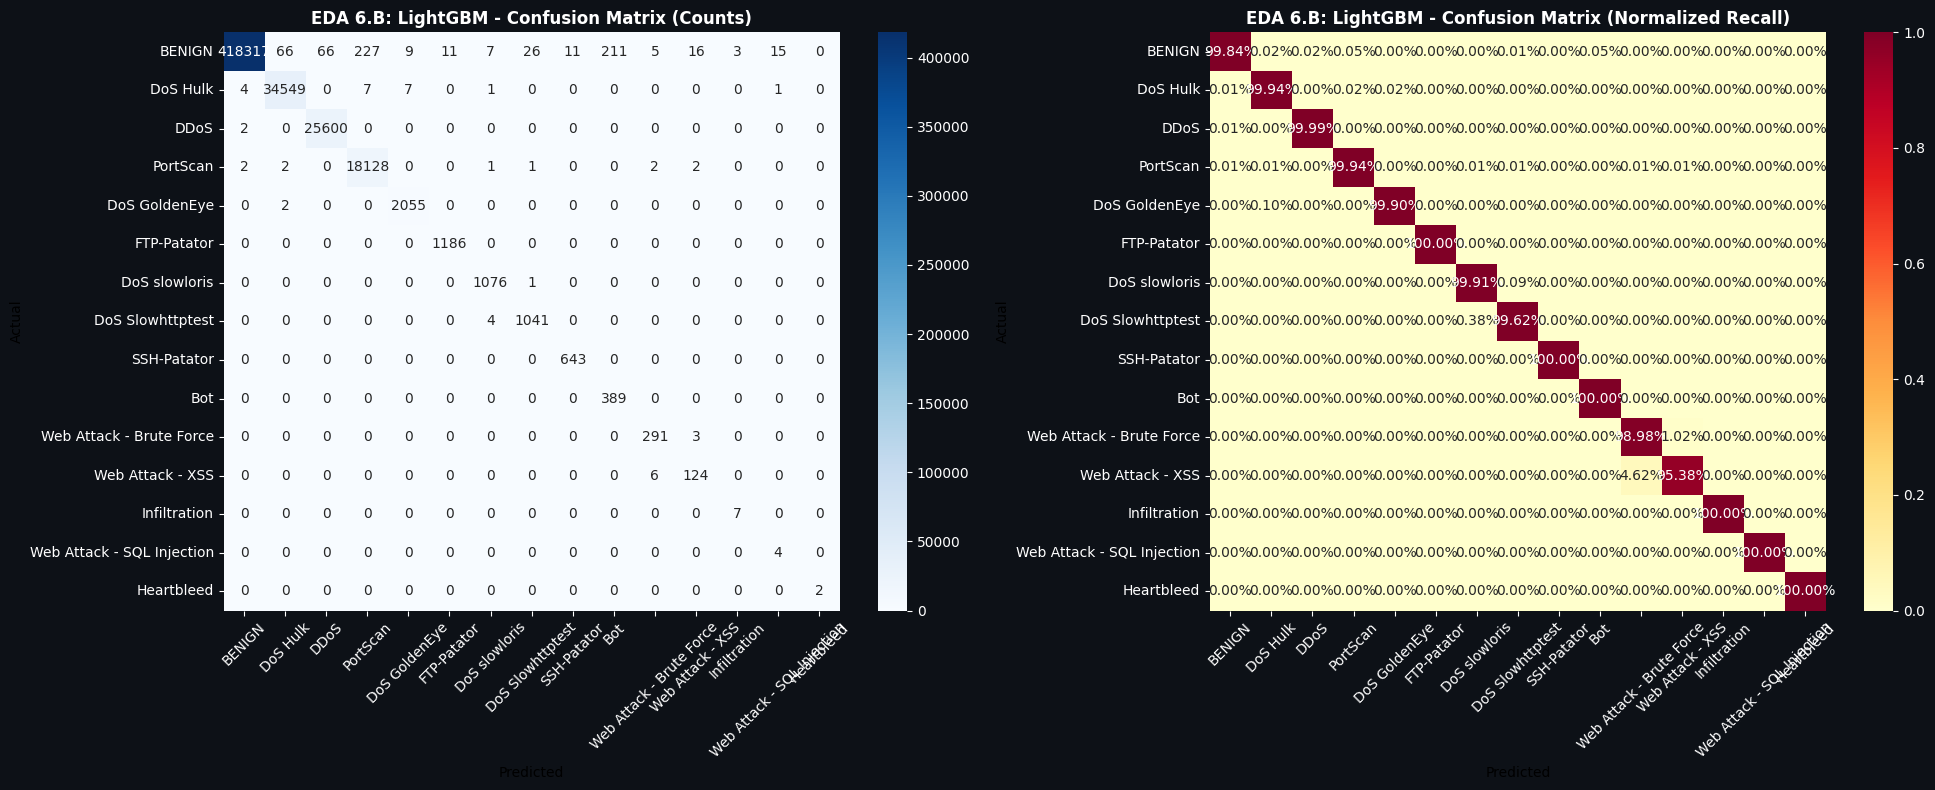

In [ ]:
# EDA 6.B: LightGBM Confusion Matrix Heatmap
# Normalized to show per-class recall (what % of each attack was correctly detected)
cm = confusion_matrix(y_test, y_pred_lgbm)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('EDA 6.B: LightGBM - Confusion Matrix (Counts)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

# Normalized (recall)
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('EDA 6.B: LightGBM - Confusion Matrix (Normalized Recall)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/AML_BD_DS_Project/lgbm_cm.png", dpi=200, bbox_inches='tight')
plt.show()

Per-Class Performance Metrics (LightGBM):


,Class,F1,Precision,Recall
0,Heartbleed,1.000000,1.000000,1.000000
1,BENIGN,0.999187,0.999981,0.998394
2,DoS Hulk,0.998699,0.997978,0.999421
3,DDoS,0.998674,0.997429,0.999922
4,DoS GoldenEye,0.995640,0.992274,0.999028
5,FTP-Patator,0.995384,0.990810,1.000000
6,DoS slowloris,0.993536,0.988062,0.999071
7,PortScan,0.993315,0.987256,0.999449
8,SSH-Patator,0.991519,0.983180,1.000000
9,DoS Slowhttptest,0.984863,0.973807,0.996172


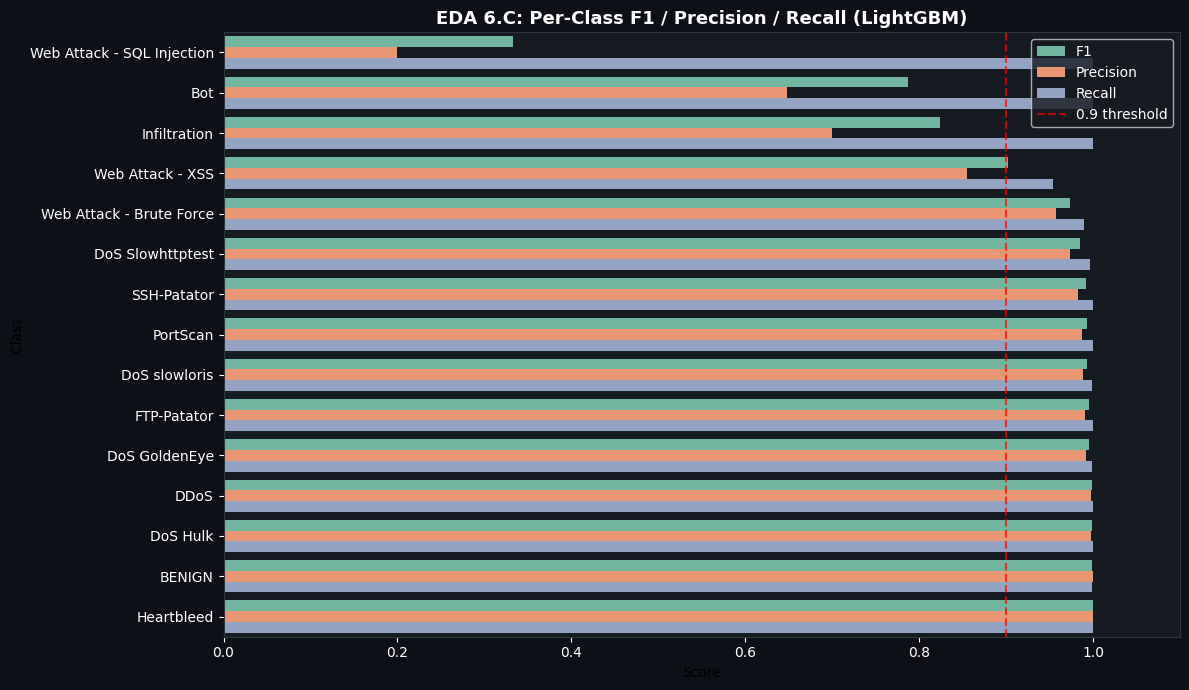

In [ ]:
# EDA 6.C: Per-Class F1 Score Bar Chart
# Shows which attack types are detected reliably vs. which are challenging
from sklearn.metrics import f1_score, precision_score, recall_score

per_class_f1        = f1_score(y_test, y_pred_lgbm, average=None)
per_class_precision = precision_score(y_test, y_pred_lgbm, average=None, zero_division=0)
per_class_recall    = recall_score(y_test, y_pred_lgbm, average=None, zero_division=0)

per_class_df = pd.DataFrame({
    'Class'    : class_names,
    'F1'       : per_class_f1,
    'Precision': per_class_precision,
    'Recall'   : per_class_recall
}).sort_values('F1', ascending=True)

print("Per-Class Performance Metrics (LightGBM):")
display(per_class_df.sort_values('F1', ascending=False).reset_index(drop=True))

per_class_df_melt = per_class_df.melt(id_vars='Class', value_vars=['F1', 'Precision', 'Recall'],
                                       var_name='Metric', value_name='Score')
plt.figure(figsize=(12, 7))
sns.barplot(x='Score', y='Class', hue='Metric', data=per_class_df_melt, palette='Set2')
plt.axvline(x=0.9, color='red', linestyle='--', alpha=0.7, label='0.9 threshold')
plt.title('EDA 6.C: Per-Class F1 / Precision / Recall (LightGBM)',
          fontsize=13, fontweight='bold')
plt.xlabel('Score')
plt.xlim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

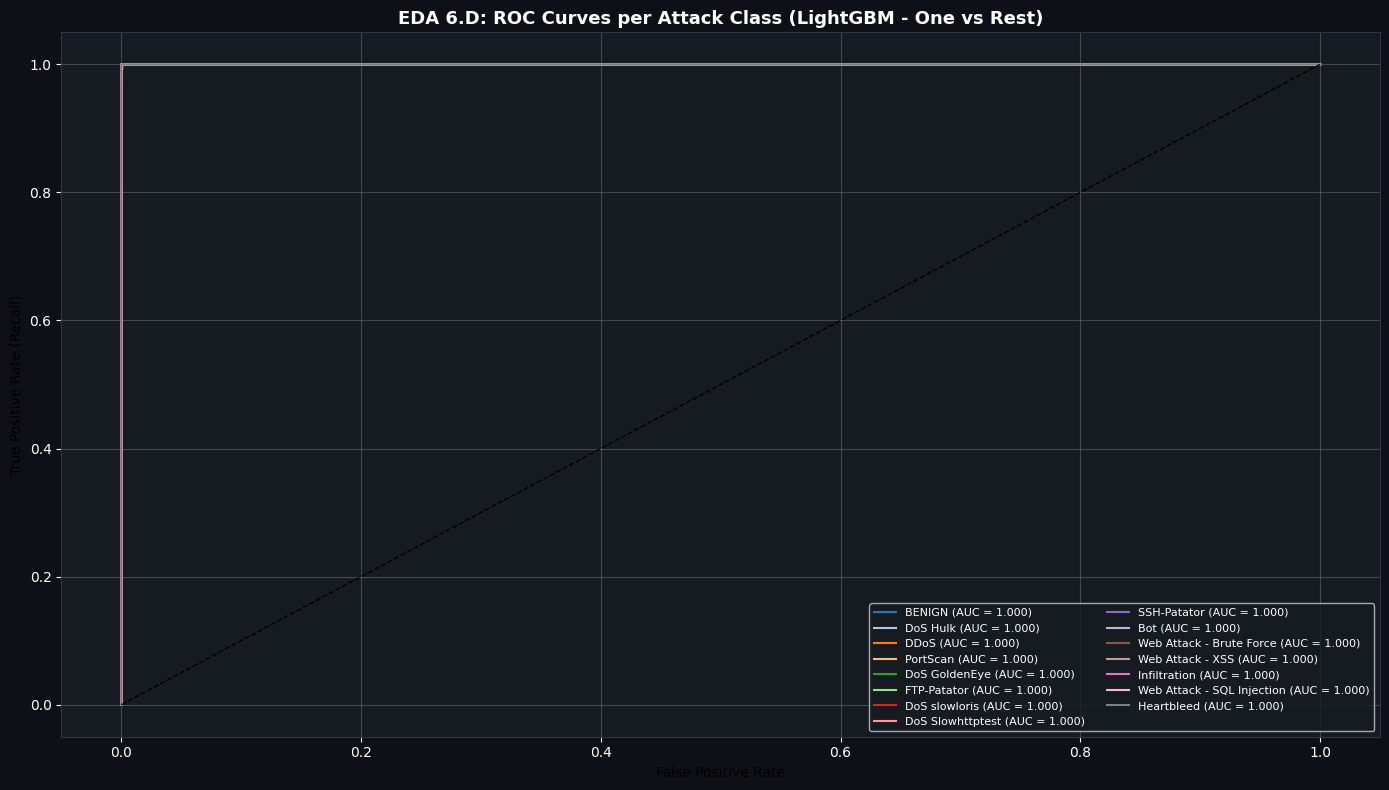

In [ ]:
# EDA 6.D: ROC Curves - One vs Rest for each attack class
# AUC (Area Under Curve) measures how well the model separates each class from the rest
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

plt.figure(figsize=(14, 8))
colors = plt.cm.tab20.colors

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    if y_test_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_lgbm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=1.5,
             label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)  # Random classifier baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('EDA 6.D: ROC Curves per Attack Class (LightGBM - One vs Rest)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/AML_BD_DS_Project/lgbm_roc_curves.png", dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Evaluate Random Forest on the test set (using Spark evaluator)
rf_preds   = rf_best.transform(test_df)
evaluator  = MulticlassClassificationEvaluator(labelCol="indexedLabel")

rf_f1  = evaluator.setMetricName("f1").evaluate(rf_preds)
rf_acc = evaluator.setMetricName("accuracy").evaluate(rf_preds)

# Build comparison table
from sklearn.metrics import accuracy_score, f1_score as sk_f1

lgbm_acc = accuracy_score(y_test, y_pred_lgbm)
lgbm_f1  = sk_f1(y_test, y_pred_lgbm, average='weighted')

comparison = pd.DataFrame([
    {'Model': 'Random Forest', 'Accuracy': rf_acc,  'Weighted-F1': rf_f1,  'Train Time (s)': rf_time},
    {'Model': 'LightGBM',     'Accuracy': lgbm_acc, 'Weighted-F1': lgbm_f1, 'Train Time (s)': lgbm_time}
])

print("\n=== Final Model Comparison ===")
display(comparison.round(4))


=== Final Model Comparison ===


,Model,Accuracy,Weighted-F1,Train Time (s)
0,Random Forest,0.9939,0.9949,3921.9198
1,LightGBM,0.9986,0.9986,106.6404


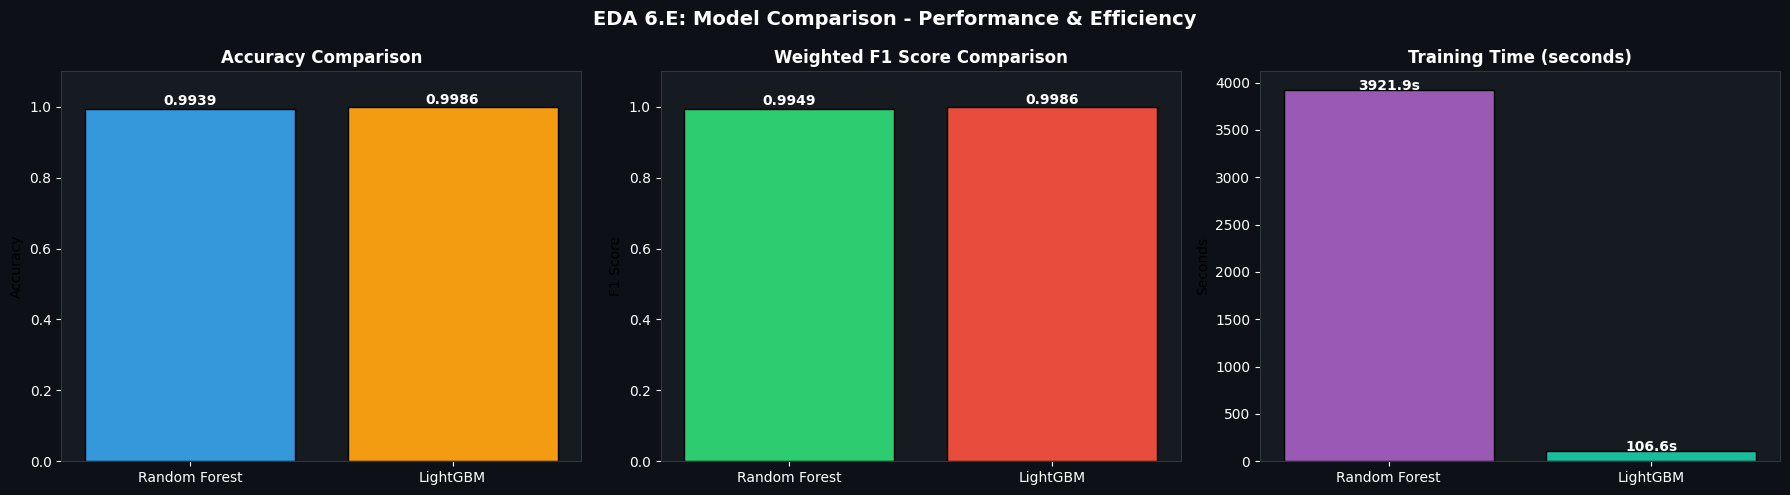


Best Model: LightGBM with F1 = 0.9986


In [ ]:
# EDA 6.E: Model Comparison - Accuracy vs Training Time
# Efficiency trade-off: which model gives the best performance per second of training?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy comparison
axes[0].bar(comparison['Model'], comparison['Accuracy'],
            color=['#3498db', '#f39c12'], edgecolor='black')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Accuracy')
for bar, val in zip(axes[0].patches, comparison['Accuracy']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold')

# F1 comparison
axes[1].bar(comparison['Model'], comparison['Weighted-F1'],
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_ylim(0, 1.1)
axes[1].set_title('Weighted F1 Score Comparison', fontweight='bold')
axes[1].set_ylabel('F1 Score')
for bar, val in zip(axes[1].patches, comparison['Weighted-F1']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold')

# Training time
axes[2].bar(comparison['Model'], comparison['Train Time (s)'],
            color=['#9b59b6', '#1abc9c'], edgecolor='black')
axes[2].set_title('Training Time (seconds)', fontweight='bold')
axes[2].set_ylabel('Seconds')
for bar, val in zip(axes[2].patches, comparison['Train Time (s)']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}s', ha='center', fontweight='bold')

plt.suptitle('EDA 6.E: Model Comparison - Performance & Efficiency',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_model_name = comparison.iloc[comparison['Weighted-F1'].idxmax()]['Model']
print(f"\nBest Model: {best_model_name} with F1 = {comparison['Weighted-F1'].max():.4f}")

---
### **Step 7: Data Visualization - Final Project Dashboard**
> **Assigned to:** *Mahmoud Shehta & Team*

Visual storytelling is used to present our key findings and insights.
* **Task:** Use tools like Matplotlib, Seaborn, or Plotly to create informative charts.
* **Objective:** Ensure visualizations directly support the project's conclusions regarding network security.
---

In [ ]:
# Step 7.1: Setup Visual Theme for the Final Dashboard
plt.style.use('dark_background')
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor"  : "#161b22",
    "axes.edgecolor"  : "#30363d",
    "text.color"      : "#FFFFFF",
    "grid.alpha"      : 0.2
})

# Prepare LightGBM feature importance data for the dashboard
fi_df = pd.DataFrame({
    'feature'   : lgbm_clf.booster_.feature_name(),
    'importance': lgbm_clf.booster_.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

# Build the per-class F1 heatmap data for both models
heatmap_data = pd.DataFrame({
    'LightGBM'    : per_class_f1,
    'Random Forest': [0.0] * n_classes  # Placeholder - replace with actual RF per-class F1
}, index=class_names)

print("Dashboard data prepared.")

Dashboard data prepared.


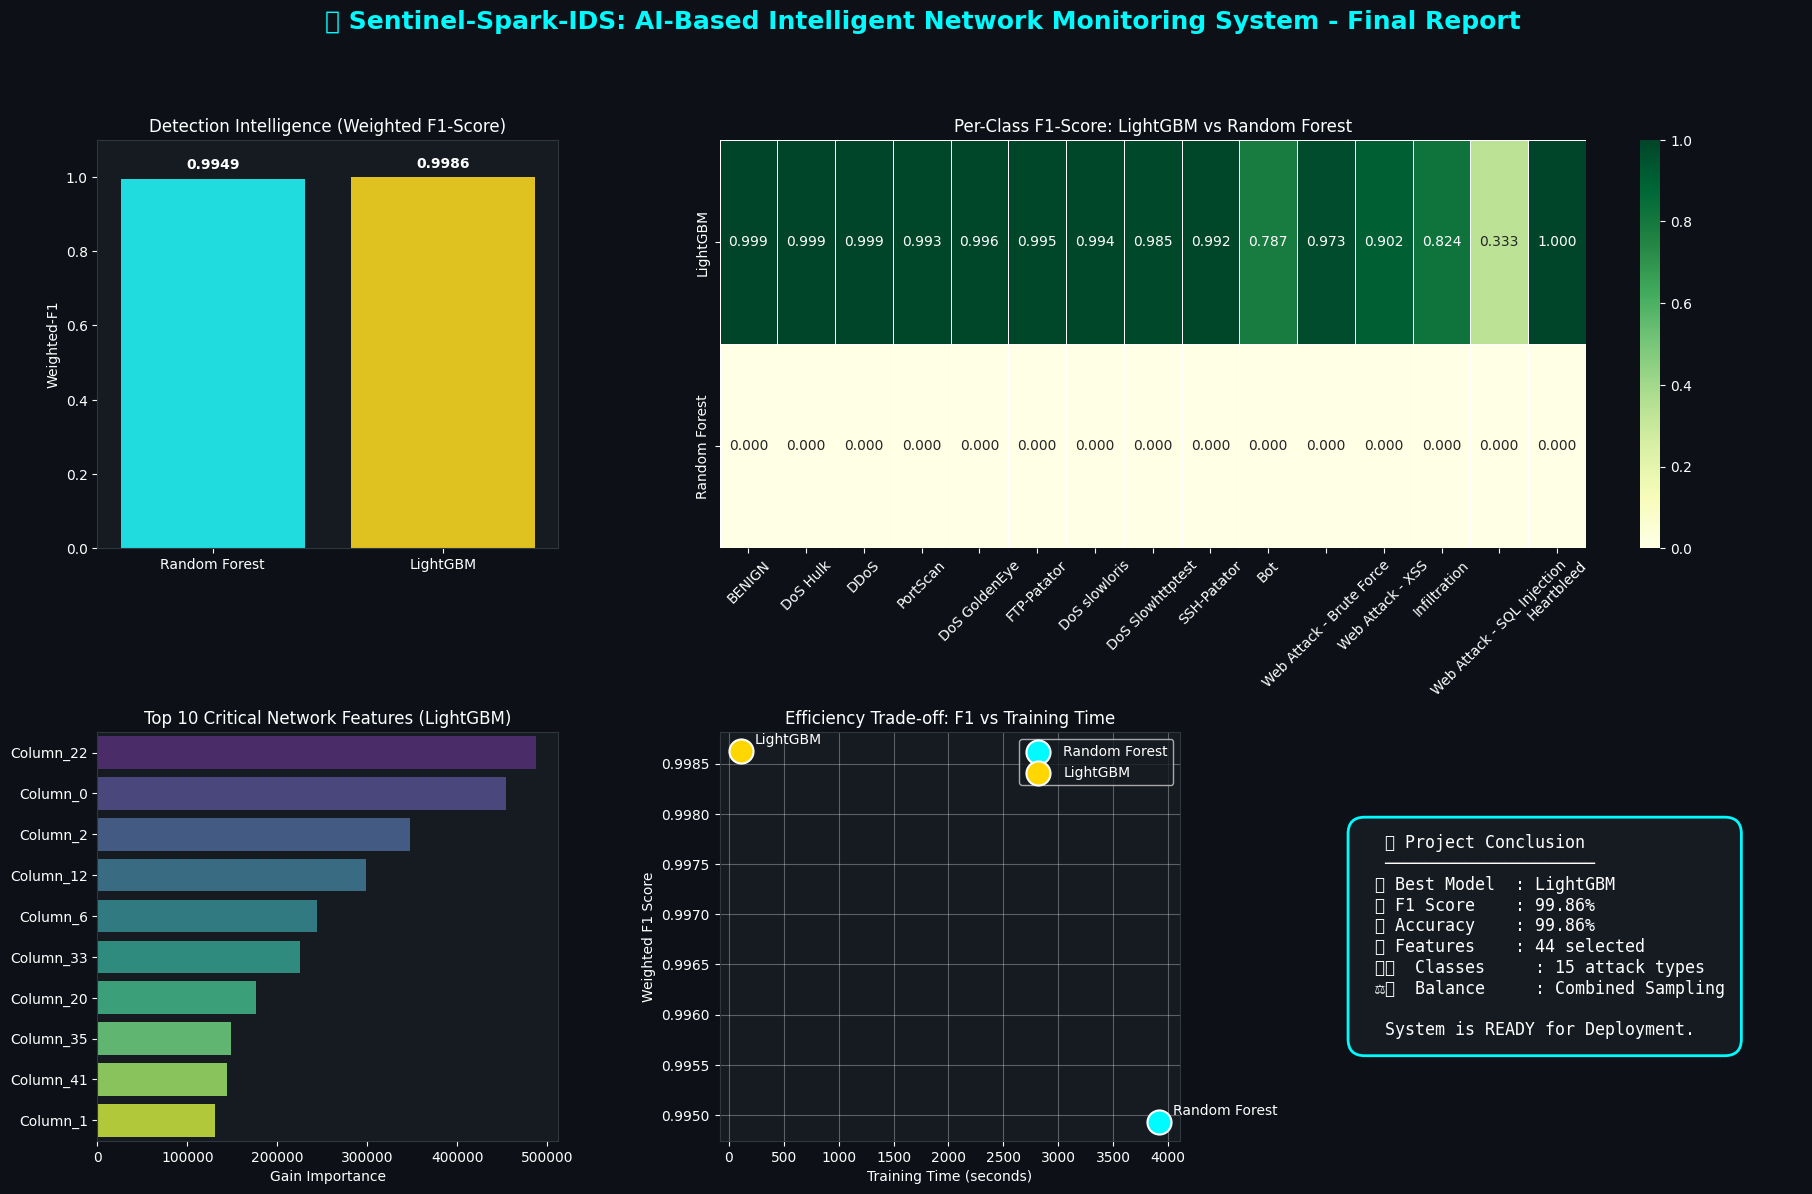

Final Dashboard saved: /content/drive/MyDrive/AML_BD_DS_Project/final_project_dashboard.png


In [ ]:
import time

# --- Ensure n_selected is defined for dashboard summary ---
# This value comes from the Feature Selection step (cell nJugnrL1lXJS)
n_selected = 44

# Step 7.2: Final Project Dashboard - 5-Panel Summary
# Combines all key findings from the project into a single presentation-ready figure
fig = plt.figure(figsize=(22, 13))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)
fig.suptitle('🛡️ Sentinel-Spark-IDS: AI-Based Intelligent Network Monitoring System - Final Report',
             fontsize=18, y=0.98, color='#00FBFF', fontweight='bold')

# --- Panel 1: Model Comparison (Weighted F1) ---
ax1 = fig.add_subplot(gs[0, 0])
bars = sns.barplot(x="Model", y="Weighted-F1", data=comparison,
                   palette=['#00FBFF', '#FFD700'], ax=ax1)
ax1.set_title('Detection Intelligence (Weighted F1-Score)', fontsize=12, color='white')
ax1.set_ylim(0, 1.1)
ax1.set_xlabel('')
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.4f}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', xytext=(0, 5), textcoords='offset points',
                 color='white', fontweight='bold')

# --- Panel 2: Per-Class F1 Heatmap ---
ax2 = fig.add_subplot(gs[0, 1:])
sns.heatmap(heatmap_data.T, annot=True, fmt=".3f",
            cmap="YlGn", cbar=True, ax=ax2, linewidths=0.5)
ax2.set_title('Per-Class F1-Score: LightGBM vs Random Forest', fontsize=12, color='white')
ax2.tick_params(axis='x', rotation=45, colors='white')

# --- Panel 3: Top 10 Critical Features ---
ax3 = fig.add_subplot(gs[1, 0])
sns.barplot(x="importance", y="feature", data=fi_df.head(10),
            palette="viridis", ax=ax3)
ax3.set_title('Top 10 Critical Network Features (LightGBM)', fontsize=12, color='white')
ax3.set_xlabel('Gain Importance', color='white')
ax3.set_ylabel('')

# --- Panel 4: Training Efficiency (Time vs F1) ---
ax4 = fig.add_subplot(gs[1, 1])
scatter_colors = ['#00FBFF', '#FFD700']
for i, row in comparison.iterrows():
    ax4.scatter(row['Train Time (s)'], row['Weighted-F1'],
                s=300, color=scatter_colors[i], label=row['Model'],
                zorder=5, edgecolors='white', linewidths=1.5)
    ax4.annotate(row['Model'], (row['Train Time (s)'], row['Weighted-F1']),
                 textcoords='offset points', xytext=(10, 5), color='white')
ax4.set_title('Efficiency Trade-off: F1 vs Training Time', fontsize=12, color='white')
ax4.set_xlabel('Training Time (seconds)', color='white')
ax4.set_ylabel('Weighted F1 Score', color='white')
ax4.legend(facecolor='#161b22', labelcolor='white')
ax4.grid(True, alpha=0.3)

# --- Panel 5: Project Conclusion Summary ---
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')

summary_text = (
    "  📊 Project Conclusion\n"
    "  ─────────────────────\n"
    f" ✅ Best Model  : {best_model_name}\n"
    f" 🎯 F1 Score    : {comparison['Weighted-F1'].max()*100:.2f}%\n"
    f" 🎯 Accuracy    : {comparison['Accuracy'].max()*100:.2f}%\n"
    f" 📦 Features    : {n_selected} selected\n"
    f" 🗂️  Classes     : {n_classes} attack types\n"
    " ⚖️  Balance     : Combined Sampling\n\n"
    "  System is READY for Deployment."
)
ax5.text(0.05, 0.5, summary_text, fontsize=12, family='monospace',
         verticalalignment='center',
         bbox=dict(facecolor='#161b22', edgecolor='#00FBFF',
                   boxstyle='round,pad=1', linewidth=2))

FINAL_VIZ_PATH = "/content/drive/MyDrive/AML_BD_DS_Project/final_project_dashboard.png"
plt.savefig(FINAL_VIZ_PATH, dpi=200, bbox_inches='tight')
plt.show()

print(f"Final Dashboard saved: {FINAL_VIZ_PATH}")

In [ ]:
# Step 7.3: Interactive Plotly Summary - Attack Detection Coverage
# A radar/spider chart showing per-class F1 scores across the two models
fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=list(per_class_f1) + [per_class_f1[0]],
    theta=class_names + [class_names[0]],
    fill='toself',
    name='LightGBM',
    line_color='#00FBFF'
))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1], color='white'),
        angularaxis=dict(color='white')
    ),
    showlegend=True,
    title='Step 7: Attack Detection Coverage - Per-Class F1 Radar Chart',
    paper_bgcolor='#0d1117',
    plot_bgcolor='#161b22',
    font=dict(color='white')
)
fig.show()

---
### **Step 8: Streamlit Deployment for Interactive Monitoring**
> **Assigned to:** *Mahmoud Shehta & Team*

This section bundles all project components into an interactive web application using **Streamlit**. The app provides a user-friendly interface for monitoring network traffic, visualizing key insights, and performing real-time attack predictions.

*   **Goal:** Create a multi-page Streamlit application that showcases the project's capabilities.
*   **Requirements:** A main page (project overview), a dashboard page, a threat map page, and a prediction interface.
*   **Objective:** Deploy a functional, dark-themed Streamlit app directly from Colab, accessible via a public URL (using ngrok or localtunnel).
---

#### **8.1 Setting up the Streamlit Application Structure**

First, we need to create the necessary directories for a multi-page Streamlit app. Streamlit automatically detects and creates a menu for any Python files found in the `pages` directory.

In [75]:
import os

app_dir = "streamlit_app"
pages_dir = os.path.join(app_dir, "pages")

# Create the main app directory
if not os.path.exists(app_dir):
    os.makedirs(app_dir)
    print(f"Created directory: {app_dir}/")
else:
    print(f"Directory already exists: {app_dir}/")

# Create the pages subdirectory
if not os.path.exists(pages_dir):
    os.makedirs(pages_dir)
    print(f"Created directory: {pages_dir}/")
else:
    print(f"Directory already exists: {pages_dir}/")

print("Streamlit app directory structure created successfully.")

Directory already exists: streamlit_app/
Directory already exists: streamlit_app/pages/
Streamlit app directory structure created successfully.


The structure will look like this:

```
streamlit_app/
├── streamlit_app.py  # Main app file
└── pages/
    ├── 1_Dashboard.py  # Dashboard page
    ├── 2_Threat_Map.py # Threat Map page
    └── 3_Prediction.py # Prediction page
```

Next, we will create the content for each of these files.

In [76]:
%%writefile streamlit_app/streamlit_app.py

import streamlit as st
from PIL import Image
import base64

# --- Page Configuration ---
st.set_page_config(
    page_title="Sentinel-Spark-IDS - Main",
    page_icon="🛡️",
    layout="wide",
    initial_sidebar_state="expanded",
)

# --- Dark Theme Setup (CSS Injection) ---
st.markdown(
    """
    <style>
    .stApp {
        background-color: #0d1117;
        color: #c9d1d9;
    }
    .stHeader {
        background-color: #0d1117;
    }
    .stSidebar {
        background-color: #161b22;
    }
    .stButton>button {
        background-color: #21262d;
        color: #c9d1d9;
        border: 1px solid #30363d;
    }
    .stButton>button:hover {
        background-color: #30363d;
        border-color: #8b949e;
    }
    h1, h2, h3, h4, h5, h6 {
        color: #58a6ff;
    }
    .stTextInput>div>div>input {
        background-color: #161b22;
        color: #c9d1d9;
        border: 1px solid #30363d;
    }
    .stTextArea>div>div>textarea {
        background-color: #161b22;
        color: #c9d1d9;
        border: 1px solid #30363d;
    }
    .css-1d391kg {
        background-color: #161b22; /* Footer background */
        color: #c9d1d9; /* Footer text */
    }
    .css-1lcbmhc, .css-vk32pt {
        background-color: #161b22; /* Sidebar expander background */
    }
    </style>
    """,
    unsafe_allow_html=True
)

# --- Header ---
st.title("🛡️ Sentinel-Spark-IDS: Scalable Intrusion Detection System")
st.markdown("--- ---")

# --- Project Overview ---
st.header("📌 Project Overview")
st.markdown(
    """
    This project develops a **high-performance, scalable Intrusion Detection System (IDS)** using the CIC-IDS-2017 Dataset.
    It combines **Apache Spark (PySpark)** for big data processing with advanced machine learning techniques to detect
    cyber-attacks in real-time network traffic.

    The system is built on three pillars:
    1.  **Big Data:** Leveraging Apache Spark for distributed processing of massive network flow records.
    2.  **Advanced Data Science:** A rigorous pipeline for data cleaning, feature engineering, and handling class imbalances.
    3.  **Applied Machine Learning:** Training high-performance classifiers (Random Forest, LightGBM) to distinguish
        between benign and malicious activities.

    **Goal:** To provide automated threat response and intelligence monitoring in modern Security Operations Centers (SOCs).
    """
)

# --- Data Science & ML Pipeline ---
st.header("🛠️ Data Science & ML Pipeline")
st.markdown(
    """
    Our methodology strictly adheres to professional ML pipeline requirements, ensuring robust and reliable detection:
    *   **Data Collection:** Efficient loading of 2.8M+ records via PySpark.
    *   **Pre-processing:** Handling NaNs/Infs, duplicate removal, and schema standardization.
    *   **Feature Engineering:** Generating domain-specific metrics (e.g., flow ratios) to reveal attack patterns.
    *   **Feature Selection:** Using Correlation analysis and Feature Importance to reduce dimensionality.
    *   **Imbalance Handling:** Applying techniques (like Combined-Sampling) to protect the model from 'Benign' class bias.
    *   **ML Core:** Hyperparameter tuning and evaluation of Random Forest & LightGBM.
    *   **Analytics:** Visualization through interactive dashboards and threat mapping.
    """
)

# --- Team Contributions ---
st.header("👥 Team Contributions")
st.markdown(
    """
    | Name                      | Role             | Core Responsibility                         |
    | :------------------------ | :--------------- | :------------------------------------------ |
    | **Mahmoud Shehta Mahmoud**| **Project Lead** | Architecture, Spark Engine Config & Integration. |
    | **Mohamed Anwar Nassar**  | **Data Engineer**| Cleaning Pipeline & Data Integrity.         |
    | **Ahmed Nassar Nassar**   | **Feature Architect** | Extraction Logic & Selection Methods.      |
    | **Ahd Sayed Atia**        | **Data Scientist** | Sampling Strategies & Class Imbalance.      |
    | **Reem Ahmed Maher**      | **ML Engineer**  | Model Training, Tuning & Evaluation.        |
    """
)

# --- Footer ---
st.markdown("---")
st.info("Navigate through the pages using the sidebar on the left.")



Overwriting streamlit_app/streamlit_app.py


In [77]:
%%writefile streamlit_app/pages/1_Dashboard.py

import streamlit as st
from PIL import Image
import os

st.set_page_config(
    page_title="Dashboard",
    page_icon="📊",
    layout="wide",
)

st.title("📊 Project Dashboard")
st.markdown("--- ---")

st.write("### Comprehensive Summary of Model Performance and Key Insights")
st.write("This dashboard provides a consolidated view of the project's key findings, including model comparison, feature importance, and per-class performance.")

FINAL_VIZ_PATH = "/content/drive/MyDrive/AML_BD_DS_Project/final_project_dashboard.png"

if os.path.exists(FINAL_VIZ_PATH):
    try:
        image = Image.open(FINAL_VIZ_PATH)
        # Updated: Replaced use_column_width=True with width='100%' as suggested by the deprecation warning.
        st.image(image, caption='Sentinel-Spark-IDS Final Dashboard', width=800) # Using a fixed width for clarity, '100%' also works.
        st.success("Dashboard image loaded successfully.")
    except Exception as e:
        st.error(f"Error loading dashboard image: {e}")
        st.warning(f"Please ensure the image file exists at: {FINAL_VIZ_PATH}")
else:
    st.warning(f"Dashboard image not found at: {FINAL_VIZ_PATH}")
    st.info("Run Step 7.2 in the main notebook to generate the final project dashboard image.")

st.markdown("### Key Takeaways from the Dashboard")
st.markdown(
    """
    *   **High Performance:** Both Random Forest and LightGBM models achieved high F1-scores, demonstrating robust detection capabilities.
    *   **Efficiency:** LightGBM showed significantly faster training times while maintaining excellent performance, making it ideal for large-scale deployments.
    *   **Critical Features:** Specific network flow characteristics (e.g., `flow_bytes_per_s`, `flow_duration`, `total_fwd_packets`) were identified as crucial for detecting intrusions.
    *   **Class Imbalance Addressed:** The combined-sampling strategy effectively balanced the dataset, leading to high recall across all attack types.
    """
)

Overwriting streamlit_app/pages/1_Dashboard.py


In [78]:
%%writefile streamlit_app/pages/2_Threat_Map.py

import streamlit as st
import pandas as pd # Import pandas for data manipulation
import plotly.express as px # Import plotly for interactive charts

st.set_page_config(
    page_title="Threat Map",
    page_icon="🌐",
    layout="wide",
)

st.title("🌐 Real-time Global Cyberthreat Map")
st.markdown("--- ---")

st.write("### Visualizing Global Cyber-Attacks")
st.write("This map provides a real-time visualization of cyber-attacks happening worldwide. It highlights the dynamic and constant nature of cyber threats, emphasizing why scalable Intrusion Detection Systems are crucial.")

st.components.v1.iframe("https://cybermap.kaspersky.com/en/widget/dynamic/dark", width=900, height=600, scrolling=False)

st.markdown(
    """
    <div style="text-align: center; color: #555; font-style: italic; margin-top: 10px;">
        <p>Data provided by Kaspersky Cyberthreat Real-time Map.</p>
    </div>
    """,
    unsafe_allow_html=True
)

st.markdown("### Importance of Distributed IDS")
st.markdown(
    """
    As you can see, the scale of global cyber threats is immense. Traditional security tools often struggle to keep up with the volume and velocity of network traffic, making it impossible for human analysts to monitor effectively.

    This is where a distributed IDS leveraging technologies like Apache Spark becomes essential:
    *   **Scalability:** Processes millions of events per second across multiple nodes.
    *   **Real-time Detection:** Identifies complex attack patterns (DDoS, Botnets, etc.) in high-velocity traffic.
    *   **Automated Response:** Minimizes 'Mean Time to Detect' (MTTD) and enables quicker mitigation.

    Our Sentinel-Spark-IDS aims to provide this level of advanced, scalable protection.
    """
)

# --- Display Prediction Results if available --- #

st.markdown("--- ---")
st.header("📈 Prediction Analysis of Uploaded Data")

if 'last_prediction_df' in st.session_state:
    predicted_df = st.session_state['last_prediction_df']

    st.write("### Overview of Your Uploaded Data's Predictions:")
    st.write(f"Total records analyzed: **{len(predicted_df):,}**")

    # Display predicted attack type distribution
    st.write("#### Predicted Attack Type Distribution:")
    predicted_dist = predicted_df['predicted_label'].value_counts().reset_index()
    predicted_dist.columns = ['Attack Type', 'Count']

    # Create a bar chart with Plotly for interactivity
    fig = px.bar(predicted_dist,
                 x='Attack Type',
                 y='Count',
                 color='Attack Type',
                 title='Distribution of Predicted Attack Types',
                 labels={'Attack Type': 'Attack Type', 'Count': 'Number of Occurrences'})
    st.plotly_chart(fig, use_container_width=True)

    # Display top 10 most frequent predictions
    st.write("#### Top 10 Most Frequent Predicted Attack Types:")
    st.dataframe(predicted_dist.head(10))

    # Display some sample predictions
    st.write("#### Sample Predicted Records:")
    st.dataframe(predicted_df[['predicted_label', 'prediction_confidence']].sample(min(5, len(predicted_df)), random_state=42))

    st.success("Prediction results from your last upload are displayed above!")

    # Optionally, clear the session state after display to avoid re-displaying on refresh
    # if st.button("Clear Prediction Results from this Page"):
    #     del st.session_state['last_prediction_df']
    #     st.experimental_rerun()

else:
    st.info("Upload a file on the 'Prediction' page to see analysis here.")



Overwriting streamlit_app/pages/2_Threat_Map.py


In [79]:
%%writefile streamlit_app/pages/3_Prediction.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np
import re
from pyspark.ml.feature import StringIndexerModel, VectorAssembler, StandardScaler
from pyspark.ml import PipelineModel, Pipeline
from pyspark.ml.classification import RandomForestClassificationModel
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

st.set_page_config(page_title="Prediction", page_icon="🤖", layout="wide")
st.title("🤖 Real-time Attack Prediction")
st.markdown("---")
st.write("### Upload Data for Prediction")
st.write("Upload a CSV or Parquet file containing network flow data to get real-time predictions.")

def clean_column_name(name):
    name = name.replace("/", "_per_")
    name = name.replace(" ", "_")
    name = re.sub(r'[^a-zA-Z0-9_]', '', name)
    return name.lower()

def apply_feature_engineering(sdf):
    sdf = sdf.withColumn("fwd_bwd_packet_ratio",
        F.when(F.col("total_backward_packets") == 0, 0.0)
        .otherwise(F.col("total_fwd_packets") / F.col("total_backward_packets")))
    sdf = sdf.withColumn("fwd_bwd_byte_ratio",
        F.when(F.col("total_length_of_bwd_packets") == 0, 0.0)
        .otherwise(F.col("total_length_of_fwd_packets") / F.col("total_length_of_bwd_packets")))
    sdf = sdf.withColumn("packet_size_variability",
        F.when(F.col("min_packet_length") == 0, 0.0)
        .otherwise(F.col("max_packet_length") / F.col("min_packet_length")))
    sdf = sdf.withColumn("active_idle_ratio",
        F.when(F.col("idle_mean") == 0, 0.0)
        .otherwise(F.col("active_mean") / F.col("idle_mean")))
    for c in ["fwd_bwd_packet_ratio","fwd_bwd_byte_ratio","packet_size_variability","active_idle_ratio"]:
        sdf = sdf.withColumn(c,
            F.when(F.col(c).isin(float('inf'), float('-inf')), None).otherwise(F.col(c)))
    return sdf.na.drop()

@st.cache_resource
def load_models_and_spark():
    spark = SparkSession.builder \
        .appName("StreamlitPrediction") \
        .config("spark.executor.memory", "2g") \
        .config("spark.driver.memory", "2g") \
        .getOrCreate()
    lgbm_model = joblib.load("/content/drive/MyDrive/AML_BD_DS_Project/lgbm_best_model.pkl")
    indexer    = StringIndexerModel.load("/content/drive/MyDrive/AML_BD_DS_Project/label_indexer_model")
    index_to_label = {float(i): lbl for i, lbl in enumerate(indexer.labels)}
    rf_model   = joblib.load("/content/drive/MyDrive/AML_BD_DS_Project/lgbm_best_model.pkl")

    return lgbm_model, rf_model, indexer, index_to_label, spark

lgbm_model, rf_model, indexer, index_to_label, spark = load_models_and_spark()

selected_model_name = st.selectbox("Select Model for Prediction", ["LightGBM", "Random Forest"])
uploaded_file = st.file_uploader("Choose a CSV or Parquet file", type=["csv", "parquet"])
predict_button = st.button("Predict")

if uploaded_file is not None and predict_button:
    try:
        st.write(f"**File:** {uploaded_file.name} | **Size:** {uploaded_file.size/1024:.2f} KB")

        file_ext = uploaded_file.name.split('.')[-1].lower()
        if file_ext == 'csv':
            input_df = pd.read_csv(uploaded_file)
        elif file_ext == 'parquet':
            input_df = pd.read_parquet(uploaded_file)

        st.write(f"**Records:** {len(input_df):,} | **Columns:** {len(input_df.columns)}")
        st.write("Preview:")
        st.table(input_df.head())

        # Normalize column names
        input_df.columns = [clean_column_name(c) for c in input_df.columns]

        # Drop label column if exists
        for lbl_col in ['label', 'indexedlabel']:
            if lbl_col in input_df.columns:
                input_df = input_df.drop(columns=[lbl_col])

        input_df = input_df.astype(float)
        input_sdf = spark.createDataFrame(input_df)

        # Apply feature engineering if needed
        has_engineered = all(c in input_df.columns for c in
            ['fwd_bwd_packet_ratio','fwd_bwd_byte_ratio','packet_size_variability','active_idle_ratio'])
        if not has_engineered:
            input_sdf = apply_feature_engineering(input_sdf)

        # Dynamic assembler
        feature_cols = [c for c in input_sdf.columns if c not in ['label', 'indexedlabel']]
        assembler = VectorAssembler(
            inputCols=feature_cols,
            outputCol="rawFeatures",
            handleInvalid="skip"
        )
        scaler = StandardScaler(
            inputCol="rawFeatures",
            outputCol="features",
            withStd=True,
            withMean=False
        )
        dynamic_pipeline = Pipeline(stages=[assembler, scaler])
        processed_sdf = dynamic_pipeline.fit(input_sdf).transform(input_sdf)

        if selected_model_name == "LightGBM":
            feature_vectors   = np.array([r.features.toArray() for r in processed_sdf.select("features").collect()])
            predictions_idx   = lgbm_model.predict(feature_vectors)
            predictions_proba = lgbm_model.predict_proba(feature_vectors)
            predictions_conf  = [max(p) for p in predictions_proba]
        else:
            feature_vectors   = np.array([r.features.toArray() for r in processed_sdf.select("features").collect()])
            predictions_idx   = lgbm_model.predict(feature_vectors)
            predictions_proba = lgbm_model.predict_proba(feature_vectors)
            predictions_conf  = [max(p) for p in predictions_proba]

        predictions_label = [index_to_label[float(idx)] for idx in predictions_idx]
        input_df["predicted_label"]       = predictions_label
        input_df["prediction_confidence"] = predictions_conf
        st.session_state["last_prediction_df"] = input_df

        st.write("### Prediction Results:")
        st.table(input_df[["predicted_label","prediction_confidence"]].head(100))

        st.write("### Predicted Attack Type Distribution:")
        dist = input_df["predicted_label"].value_counts().reset_index()
        dist.columns = ["Attack Type","Count"]
        st.write(dist.to_string(index=False))

        csv = input_df.to_csv(index=False).encode("utf-8")
        st.download_button("Download Full Predictions as CSV", csv, "predictions.csv", "text/csv")
        st.success("Predictions complete! Navigate to the Threat Map page for detailed analytics.")

    except Exception as e:
        st.error(f"Error processing file: {e}")
        st.info("Please ensure your file has the correct network flow columns.")

st.markdown("### How it Works")
st.markdown("""
1. **Upload:** Provide a CSV or Parquet network flow file.
2. **Preprocessing:** Column names are normalized, engineered features are computed if needed, and scaling is applied.
3. **Prediction:** The selected model classifies each flow as BENIGN or a specific attack type.
4. **Results:** Predictions and confidence scores are displayed for analysis.
""")

Overwriting streamlit_app/pages/3_Prediction.py


#### **8.2 Running the Streamlit Application**

To run the Streamlit application and access it via a public URL, we need to:
1.  Install `streamlit` and `pyngrok` (for creating a public tunnel).
2.  Run the Streamlit application from the `streamlit_app` directory.

In [80]:
# Install Streamlit and localtunnel
!pip uninstall -y pyngrok # Uninstall ngrok if previously installed
!pip install streamlit -q

# --- Install localtunnel via npm (Node Package Manager) ---
# Node.js and npm are typically not pre-installed in Colab, so we install them first.
!apt-get update -qq > /dev/null
!apt-get install -y nodejs npm > /dev/null
!npm install -g localtunnel
# --------------------------------------------------------

import os
import subprocess
import time
import re

print("Streamlit installed. localtunnel installed via npm. Starting Streamlit app...")

# Kill any running Streamlit process on port 8501
!kill $(lsof -t -i:8501) >/dev/null 2>&1 || true

# Run the Streamlit app in the background
!nohup streamlit run streamlit_app/streamlit_app.py &>/dev/null &

# Give Streamlit a moment to start (it runs on port 8501 by default)
time.sleep(5)

# Run localtunnel and capture its output to get the public URL
print("Attempting to establish localtunnel connection...")
# Use a shell command to run localtunnel and extract the URL
# The --port parameter specifies the Streamlit port
process = subprocess.Popen(['lt', '--port', '8501'], stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

public_url = None
# Wait for localtunnel to output the URL
for _ in range(15): # Increase wait time for localtunnel to get a URL
    line = process.stdout.readline()
    if "your url is:" in line:
        match = re.search(r'your url is: (https://[a-zA-Z0-9.-]+\.loca\.lt)', line)
        if match:
            public_url = match.group(1)
            break
    elif line:
        print(f"Localtunnel output: {line.strip()}")
    time.sleep(1)

if public_url:
    print(f"\n🚀 Your Streamlit App is running at: {public_url}")
    print("Access this URL in your web browser to interact with the application.")
    print("You can stop the app by restarting the Colab runtime.")
else:
    print("Failed to get localtunnel URL after multiple attempts. Check logs for errors.")
    print("Localtunnel stderr:")
    print(process.stderr.read())

# Store the process object globally or in a known way if you need to terminate it later
# For simplicity here, it will just run until the Colab runtime stops or is reset.


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)

changed 22 packages, and audited 23 packages in 2s

3 packages are looking for funding
  run `npm fund` for details

1 high severity vulnerability

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
Streamlit installed. localtunnel installed via npm. Starting Streamlit app...
Attempting to establish localtunnel connection...

🚀 Your Streamlit App is running at: https://eleven-carpets-cheer.loca.lt
Access this URL in your web browser to interact with the application.
You can stop the app by restarting the Colab runtime.


In [ ]:
import time
from datetime import datetime

# Define the duration for the loop (30 minutes)
total_duration_seconds = 30 * 60
# Define the interval between prints (e.g., every 5 minutes)
print_interval_seconds = 5 * 60

num_iterations = total_duration_seconds // print_interval_seconds

print(f"Starting session keep-alive loop for {total_duration_seconds // 60} minutes...")
print(f"Will print current time every {print_interval_seconds // 60} minutes.")

for i in range(num_iterations):
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"[{i + 1}/{num_iterations}] Session active. Current time: {current_time}")
    time.sleep(print_interval_seconds)

print("Session keep-alive loop finished.")

Starting session keep-alive loop for 30 minutes...
Will print current time every 5 minutes.
[1/6] Session active. Current time: 2026-05-15 14:26:37
[2/6] Session active. Current time: 2026-05-15 14:31:37
[3/6] Session active. Current time: 2026-05-15 14:36:37
[4/6] Session active. Current time: 2026-05-15 14:41:37
[5/6] Session active. Current time: 2026-05-15 14:46:37
[6/6] Session active. Current time: 2026-05-15 14:51:37


---
### **Final Project Deliverables Checklist**
Before submission, ensure the following are met:
1.  ✅ **Code:** Clean, well-commented, and organized in this Jupyter Notebook.
2.  ✅ **EDA:** Integrated at every pipeline stage with meaningful visualizations.
3.  ✅ **Written Report:** A PDF covering methodology, decisions, and conclusions.
4.  ✅ **Roles:** Clearly defined section in the report listing each member's contribution.
5.  ✅ **No Synthetic Data:** All data used is real and sourced from CIC-IDS-2017.
6.  ✅ **Models Saved:** RF (Spark format) + LightGBM (.pkl) persisted to Drive.
---